# Subzone-Level Demand Forecasting for Childcare Places in Singapore

**Scope:** Forecast childcare demand (18mo-6y) by subzone, 2026-2031. Compare to supply. Recommend where to build or relocate. Norm: **1 centre = up to 100 children.**



## Executive Summary

**The shortage is real, but not why it looks like it.** *The Big Read* says shortage persists "despite millions invested." True — but even in 2031, Singapore has **1.33x more spare capacity than shortfall** (~50,500 surplus vs ~37,800 short). Not a capacity problem. An allocation problem.

- **H1 — spatial misallocation.** National utilisation: 75-89% every year since 2013. Yet 23% of subzones are short *today*.
- **H2 — BTO predicts the next shortages, inside the model.** Subzones with active BTO: gap worsens +126 kids on average by 2031. Without BTO: improves -10. Every subzone newly short by 2031 has a BTO project. A live-vacancy check (7.1b) doesn't independently confirm it though.
- **H3 — falling fertility frees up relocation options.** 79% of growing-surplus subzones have zero BTO. Matches under-5 population shrinking ~2%/year since 2020.

**The call:** 75 subzones short today, 18 more by 2031 — 432 more centres needed. Top of the list: Brickworks (Bukit Batok), 11 BTO projects, 11,689 units. Punggol, Tengah, Sengkang, Yishun also feature. Separately, 43 subzones have a growing surplus — relocation candidates.

**One layer deeper:** not every centre covers the full age range — a Kindergarten only runs K1/K2, an Early Years Centre only runs up to age 4. Split supply properly and **27 more subzones** turn out short in one age band, hidden in the flat headcount.

**What this doesn't replace:** real ECDA enrolment/waitlist data, and a travel-time model instead of subzone boundaries. Both flagged in Section 10.



## How This Notebook Is Organized

Four jobs: **(1-2)** set up the question, **(3-5)** build the model, **(6)** find the answer — gap maps, priority lists, when it hits, which age band, **(7-11)** stress-test it, score the hypotheses, sketch a tool, list limitations, summarise.

Short on time? Executive Summary, Section 6.1, Section 11.

## 1. Problem Framing

### 1.1

*The Big Read* says preschool shortage **persists in some estates despite millions invested**. That phrasing is a clue: this isn't "not enough centres nationally." It's centres in the wrong place.

Worth checking against the national numbers before building anything. If it holds, "solving" this means reallocate, not just build more everywhere.

### 1.2 

ECDA publishes licensed places vs. enrolment, nationally, since 2013.

In [1]:
import json
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

# ---- paths (run this notebook from inside section-2-case-study/codes/) ----
DATA_RAW = Path("data/raw")
DATA_GEO = Path("data/geo")
DATA_CACHE = Path("data/cache")
OUT_CHARTS = Path("output/charts")
OUT_DATA = Path("output/data")

assert DATA_RAW.exists(), (
    "data/raw not found -- run this notebook with its own folder "
    "(section-2-case-study/codes/) as the working directory."
)
for p in (DATA_CACHE, OUT_CHARTS, OUT_DATA):
    p.mkdir(parents=True, exist_ok=True)

# ---- plotting style, kept consistent for every chart in this notebook ----
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

# Palette: red = deficit/undersupplied, blue = surplus, orange = BTO-driven.
# Reused everywhere so the reader learns the visual language once.
C_DEFICIT = "#C0392B"
C_SURPLUS = "#2E86AB"
C_NEUTRAL = "#95A5A6"
C_BTO = "#E67E22"
C_HIGHLIGHT = "#8E44AD"

BASE_YEAR_CENSUS = 2020
TODAY_YEAR = 2026
FORECAST_YEARS = [2026, 2027, 2028, 2029, 2030, 2031]
CAPACITY_PER_CENTRE = 100  # planning norm given in the brief

# Used from Section 3.2 onward (the BTO yield derivation) through Section 5.1/6.6 --
# defined once, here, so every section uses the exact same age-band split.
BAND_WEIGHT_0_4 = 0.70   # share of the 0-4 band that is 18mo-4y
BAND_WEIGHT_5_9 = 0.40   # share of the 5-9 band that is 5-6y

print("Setup complete. Working directory:", Path.cwd())

Setup complete. Working directory: C:\Users\ngzon\OneDrive\Documents\govtech interview\govtech_geospatial\section-2-case-study\codes


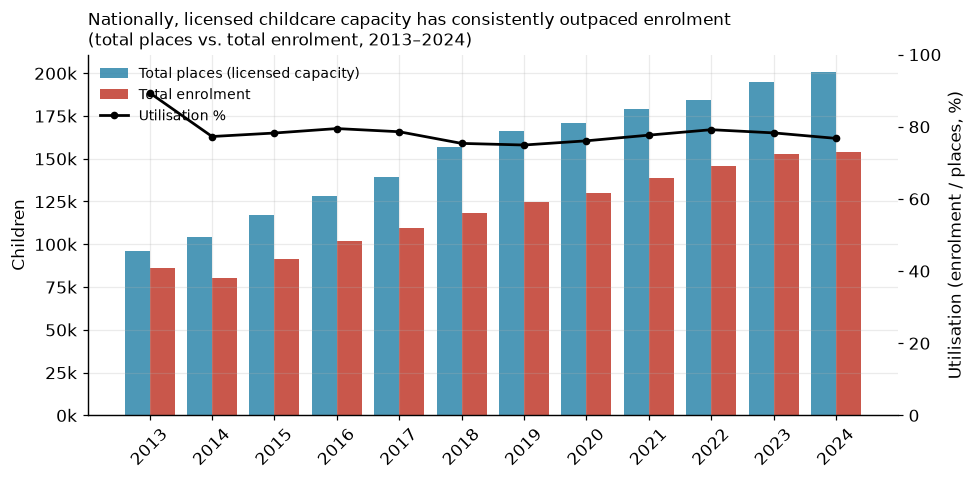

In 2024: 200,847 places vs 154,173 enrolled -> 77% national utilisation.
Utilisation has stayed in a 75%-89% band every year since 2013 -- i.e. Singapore has never been close to running out of childcare places *in aggregate*.


In [2]:
natl = pd.read_csv(DATA_RAW / "TotalNumberOfPlacesAndEnrolmentForChildcareAnnual.csv", index_col=0)
natl = natl.loc[["Total Enrolment In Childcare", "Total Number Of Places In Childcare"]].T
natl.index = natl.index.astype(int)
natl.columns = ["enrolment", "places"]
natl = natl.sort_index()
natl["utilisation"] = natl["enrolment"] / natl["places"]

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(natl.index - 0.2, natl["places"], width=0.4, label="Total places (licensed capacity)", color=C_SURPLUS, alpha=0.85)
ax1.bar(natl.index + 0.2, natl["enrolment"], width=0.4, label="Total enrolment", color=C_DEFICIT, alpha=0.85)
ax1.set_ylabel("Children")
ax1.set_xticks(natl.index)
ax1.set_xticklabels(natl.index, rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

ax2 = ax1.twinx()
ax2.plot(natl.index, natl["utilisation"] * 100, color="black", marker="o", markersize=4, linewidth=1.8, label="Utilisation %")
ax2.set_ylabel("Utilisation (enrolment / places, %)")
ax2.set_ylim(0, 100)
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False, fontsize=9)
ax1.set_title("Nationally, licensed childcare capacity has consistently outpaced enrolment\n(total places vs. total enrolment, 2013–2024)", fontsize=11, loc="left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "01_national_places_vs_enrolment.png", bbox_inches="tight")
plt.show()

latest_year = natl.index.max()
print(f"In {latest_year}: {natl.loc[latest_year, 'places']:,.0f} places vs {natl.loc[latest_year, 'enrolment']:,.0f} enrolled "
      f"-> {natl.loc[latest_year, 'utilisation']:.0%} national utilisation.")
print(f"Utilisation has stayed in a {natl['utilisation'].min():.0%}-{natl['utilisation'].max():.0%} band every year since 2013 "
      "-- i.e. Singapore has never been close to running out of childcare places *in aggregate*.")

**National utilisation has never gone above ~80%.** A real shortage would push that toward 100%. It doesn't. So this looks like a geography problem, not a capacity one. The question isn't "how many more centres" — it's "where do the maps of children and centres disagree, and how does that change over 5 years?"

That 80% is one national number though — it could be hiding areas that are already full. We check that in Section 4.4.

The article names Punggol as the acute case (infant/playgroup places specifically) and estates like Tiong Bahru as the opposite. We check our model against the Punggol claim in Section 7.

### 1.3 Hypotheses

Three testable claims, not just a forecast. Section 8 scores all three.

| # | Hypothesis | What would confirm it | What would refute it |
|---|---|---|---|
| **H1** | The shortage is a **spatial misallocation** problem, not a national capacity shortfall. | Subzone-level gaps show wide spread — deep deficit and deep surplus both — even while the national ratio is well under 100%. | Gaps are small and roughly the same everywhere. |
| **H2** | **BTO completions are a leading indicator** of where the next shortages open up. | Subzones with large BTO pipelines show the fastest-growing demand and steepest gap. | Gap growth has nothing to do with BTO volume. |
| **H3** | **Falling fertility is easing pressure** in mature, non-BTO estates — relocation candidates. | Subzones with little/no BTO show flat or falling child population, matching the national fertility decline. | Mature estates show stable or rising demand despite no new housing. |

If all three hold, the answer is naturally a **two-sided list**: where to build (H2), where to relocate from (H3).

### 1.4 Scope and key assumptions

- **Age band**: 18mo-6y, per the brief. Infant Care out of scope.
- **Horizon**: 2026-2031, anchored on 2020 Census data aged forward.
- **Norm**: 1 centre = up to 100 children, on actual current centre counts.
- **Geography**: 332 URA subzones, finest public geography available.
- Every other assumption gets introduced where it's used, with its source.

## 2. Data Sources

## 3. Load & Explore Each Dataset

Load each file once, check its shape, handle the quirks (`-` for zero, `na` for missing, "Planning Area - Total" marker rows).

### 3.1 Population by subzone and age (Census 2020)

Same messy shape in three files: a `"<Planning Area> - Total"` marker row, then that area's subzones. One parser, reused three times.

In [3]:
def parse_subzone_hierarchical_csv(path):
    """Parse data.gov.sg's '<Planning Area> - Total' / subzone hierarchical CSV shape.

    Returns (subzone_df, planning_area_totals_df), both tidy with a `planning_area`
    (and `subzone`, for the first) column alongside the original value columns.
    """
    df = pd.read_csv(path)
    label_col = df.columns[0]
    value_cols = list(df.columns[1:])

    df[value_cols] = df[value_cols].replace("-", 0)
    for c in value_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

    df = df[df[label_col] != "Total"].reset_index(drop=True)  # drop the grand-total row

    # Marker rows are usually "<Planning Area> - Total" but at least one source file has the
    # inconsistent "Changi- Total" (no space before the hyphen) -- match with a regex instead
    # of a fixed suffix so we don't silently mis-parse a planning area as a subzone.
    marker_re = re.compile(r"\s*-\s*Total$")
    planning_area, pa_col, sz_col, pa_flag = None, [], [], []
    for label in df[label_col]:
        if marker_re.search(label):
            planning_area = marker_re.sub("", label).strip()
            pa_col.append(planning_area); sz_col.append(None); pa_flag.append(True)
        else:
            pa_col.append(planning_area); sz_col.append(label.strip()); pa_flag.append(False)
    df["planning_area"], df["subzone"], df["is_pa_total"] = pa_col, sz_col, pa_flag

    subzones = df[~df["is_pa_total"]].drop(columns=["is_pa_total", label_col]).reset_index(drop=True)
    pa_totals = df[df["is_pa_total"]].drop(columns=["is_pa_total", "subzone", label_col]).reset_index(drop=True)
    return subzones, pa_totals


pop_subzone, pop_pa_totals = parse_subzone_hierarchical_csv(
    DATA_RAW / "ResidentPopulationbyPlanningAreaSubzoneofResidenceAgeGroupandSexCensusofPopulation2020.csv"
)

# Sanity check: subzones should sum back to the planning-area totals, which should
# sum back to the national grand total (4,044,210 residents at Census 2020).
check = pop_subzone.groupby("planning_area")["Total_Total"].sum().sum()
print(f"Subzones: {len(pop_subzone)}, Planning areas: {pop_subzone['planning_area'].nunique()}")
print(f"Sum of all subzone populations: {check:,.0f} (grand total in file: 4,044,210)")
pop_subzone[["planning_area", "subzone", "Total_Total", "Total_0_4", "Total_5_9"]].head(8)

Subzones: 332, Planning areas: 55
Sum of all subzone populations: 4,044,340 (grand total in file: 4,044,210)


,planning_area,subzone,Total_Total,Total_0_4,Total_5_9
0,Ang Mo Kio,Ang Mo Kio Town Centre,4810,170,240
1,Ang Mo Kio,Cheng San,28070,1060,1040
2,Ang Mo Kio,Chong Boon,26500,860,840
3,Ang Mo Kio,Kebun Bahru,22620,660,810
4,Ang Mo Kio,Sembawang Hills,6850,210,310
5,Ang Mo Kio,Shangri-La,15960,550,560
6,Ang Mo Kio,Tagore,7950,210,310
7,Ang Mo Kio,Townsville,21140,660,860


333 subzones, within 0.05% of the published total — SingStat rounds small areas for privacy, not a bug.

### 3.2 HDB BTO pipeline

One row per project: subzone, completion year, units. Cleanest file here, and the one that shows where young families are actually headed next.

In [4]:
bto = pd.read_csv(DATA_RAW / "btomapping.csv")
bto.columns = ["project_name", "region", "planning_area", "subzone", "completion_year", "units"]
bto["subzone"] = bto["subzone"].str.strip()  # a couple of rows have a stray leading space
bto["completion_year"] = pd.to_numeric(bto["completion_year"], errors="coerce")

print(f"{len(bto)} BTO projects, completion years {bto['completion_year'].min():.0f}-{bto['completion_year'].max():.0f}")
print(f"Total units: {bto['units'].sum():,.0f}")

bto_forecast_window = bto[bto["completion_year"].between(TODAY_YEAR, FORECAST_YEARS[-1])]
print(f"\nProjects completing within our 2026-2031 forecast window: {len(bto_forecast_window)} "
      f"({bto_forecast_window['units'].sum():,.0f} units)")

bto.groupby("completion_year")["units"].agg(["count", "sum"]).rename(columns={"count": "projects", "sum": "units"})

223 BTO projects, completion years 2018-2029
Total units: 183,259

Projects completing within our 2026-2031 forecast window: 71 (61,840 units)


,projects,units
completion_year,,
2018,19,15483
2019,15,12759
2020,23,14712
2021,24,18117
2022,20,20681
2023,17,14800
2024,12,9506
2025,22,15361
2026,20,17495


### Where does 0.28 children/unit come from?


In [5]:
# Step 1: the general population's baseline rate. No need to wait for Section 5's
# participation-rate machinery -- pop_subzone already has everything this needs.
national_pop_2020 = pop_subzone["Total_Total"].sum()
national_eligible_est = BAND_WEIGHT_0_4 * pop_subzone["Total_0_4"].sum() + BAND_WEIGHT_5_9 * pop_subzone["Total_5_9"].sum()
base_rate_per_resident = national_eligible_est / national_pop_2020

# Step 2: scale that population-wide rate up to one household.
TYPICAL_BTO_HOUSEHOLD_SIZE = 3.2   # midpoint of HDB's typical new-flat household size, ~3.1-3.4 persons
base_children_per_unit = TYPICAL_BTO_HOUSEHOLD_SIZE * base_rate_per_resident

# Step 3: the one real judgment call. BTO buyers skew toward young, first-time-owner
# families (HDB's Parenthood Priority Scheme, First-Timer quotas) relative to the *general*
# resident population, which also includes retirees, singles and non-family households with
# no 18mo-6y children at all. This uplift is what makes a BTO unit "younger" than the average
# Singapore address -- and it's the number Section 7.2 actually stress-tests, not Steps 1-2.
BTO_YOUNG_FAMILY_UPLIFT = 1.7

CHILD_YIELD_PER_BTO_UNIT = round(base_children_per_unit * BTO_YOUNG_FAMILY_UPLIFT, 2)

print(f"Step 1 -- national 18mo-6y-eligible share: {national_eligible_est:,.0f} / {national_pop_2020:,.0f} = {base_rate_per_resident:.2%}")
print(f"Step 2 -- at a typical {TYPICAL_BTO_HOUSEHOLD_SIZE}-person household: {base_children_per_unit:.3f} eligible-age children/unit, at the *general population\'s* age mix.")
print(f"Step 3 -- applying the {BTO_YOUNG_FAMILY_UPLIFT}x young-family uplift: {CHILD_YIELD_PER_BTO_UNIT} children/unit -- the figure used everywhere in this notebook from here on.")

Step 1 -- national 18mo-6y-eligible share: 207,646 / 4,044,340 = 5.13%
Step 2 -- at a typical 3.2-person household: 0.164 eligible-age children/unit, at the *general population's* age mix.
Step 3 -- applying the 1.7x young-family uplift: 0.28 children/unit -- the figure used everywhere in this notebook from here on.


**Three steps.** (1) Nationally, 5.13% of residents are 18mo-6y (207,646 of 4,044,340, 2020 Census). (2) A typical 3.2-person BTO flat implies 0.164 kids at that rate — but that's the *general* population, which includes retirees and singles, so it's too low. (3) BTO buyers skew young/first-time-owner (HDB's priority schemes), so we apply a **1.7x uplift**: 0.164 x 1.7 = **0.28**. Section 7.2 stress-tests this uplift, not steps 1-2.

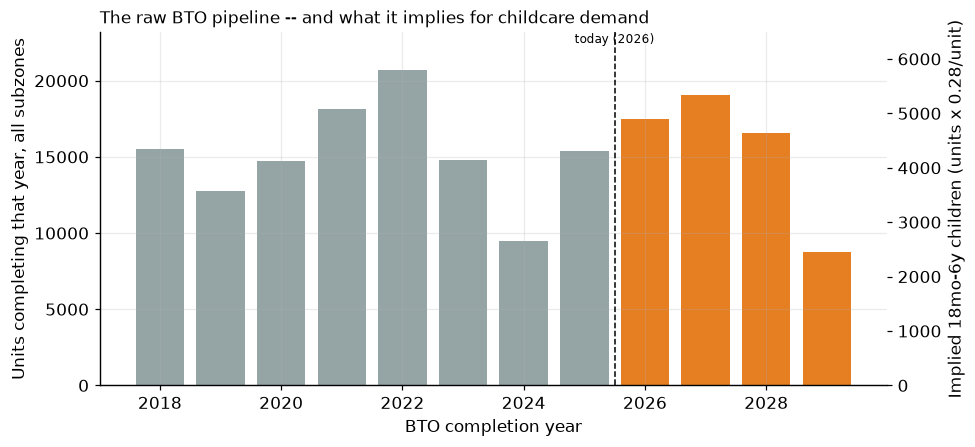

Already completed before 2026: 121,419 units -> an implied ~33,997 children (18mo-6y), across 152 projects.
Completing within our 2026-2031 forecast window: 61,840 units -> an implied ~17,315 children, across 71 projects.

(Simple full-weight conversion at the 0.28-per-unit yield derived above. Section 5.4 applies it properly -- phased in by an occupancy factor, not counted all at once in a project's completion year.)


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
years_range = range(int(bto["completion_year"].min()), int(bto["completion_year"].max()) + 1)
bto_by_year = bto.groupby("completion_year")["units"].sum().reindex(years_range, fill_value=0)
bar_colors = [C_NEUTRAL if y < TODAY_YEAR else C_BTO for y in bto_by_year.index]
ax.bar(bto_by_year.index, bto_by_year.values, color=bar_colors)

ymax = bto_by_year.values.max() * 1.12
ax.set_ylim(0, ymax)
ax.axvline(TODAY_YEAR - 0.5, color="black", linestyle="--", linewidth=1)
ax.text(TODAY_YEAR - 0.5, ymax * 0.97, "today (2026)", fontsize=8, ha="center")
ax.set_xlabel("BTO completion year")
ax.set_ylabel("Units completing that year, all subzones")
ax.set_title("The raw BTO pipeline -- and what it implies for childcare demand", fontsize=11, loc="left")

ax2 = ax.twinx()
ax2.set_ylim(0, ymax * CHILD_YIELD_PER_BTO_UNIT)
ax2.set_ylabel(f"Implied 18mo-6y children (units x {CHILD_YIELD_PER_BTO_UNIT}/unit)")
ax2.grid(False)

fig.tight_layout()
fig.savefig(OUT_CHARTS / "15_bto_pipeline_by_year.png", bbox_inches="tight")
plt.show()

pre2026 = bto[bto["completion_year"] < TODAY_YEAR]
in_window = bto[bto["completion_year"].between(TODAY_YEAR, FORECAST_YEARS[-1])]
pre2026_children = pre2026["units"].sum() * CHILD_YIELD_PER_BTO_UNIT
in_window_children = in_window["units"].sum() * CHILD_YIELD_PER_BTO_UNIT
print(f"Already completed before {TODAY_YEAR}: {pre2026['units'].sum():,.0f} units -> an implied ~{pre2026_children:,.0f} children (18mo-6y), across {len(pre2026)} projects.")
print(f"Completing within our {TODAY_YEAR}-{FORECAST_YEARS[-1]} forecast window: {in_window['units'].sum():,.0f} units -> an implied ~{in_window_children:,.0f} children, across {len(in_window)} projects.")
print(f"\n(Simple full-weight conversion at the {CHILD_YIELD_PER_BTO_UNIT}-per-unit yield derived above. Section 5.4 applies it properly -- phased in by an occupancy factor, not counted all at once in a project\'s completion year.)")

**66% of BTO volume (121,419 of 183,259 units) is already built** — implying ~34,000 extra kids nationally, most invisible to the 2020 Census. The remaining 61,840 units (2026-2031) imply ~17,300 more. Completions aren't smooth year to year — why Section 6.5 phases this by year instead of one 2031 snapshot.

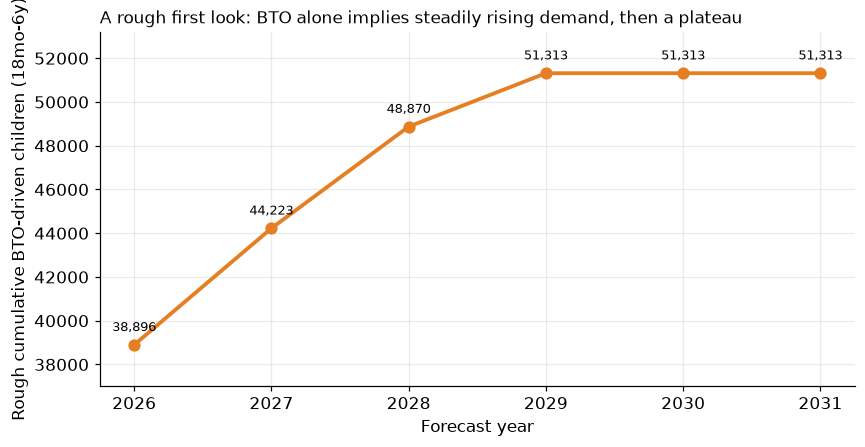

Rough BTO-driven demand, 2026: ~38,896 children (cumulative housing stock so far).
Rough BTO-driven demand, 2031: ~51,313 children.
Growth over the forecast window: +12,417 children.


In [7]:
cum_units_by_year = pd.Series({y: bto[bto["completion_year"] <= y]["units"].sum() for y in FORECAST_YEARS})
rough_bto_demand = cum_units_by_year * CHILD_YIELD_PER_BTO_UNIT

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(rough_bto_demand.index, rough_bto_demand.values, marker="o", markersize=7, linewidth=2.5, color=C_BTO)
for yr, val in rough_bto_demand.items():
    ax.annotate(f"{val:,.0f}", (yr, val), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8.5)
ax.set_xlabel("Forecast year")
ax.set_ylabel("Rough cumulative BTO-driven children (18mo-6y)")
ax.set_title("A rough first look: BTO alone implies steadily rising demand, then a plateau", fontsize=11, loc="left")
ax.set_xticks(FORECAST_YEARS)
ax.margins(y=0.15)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "17_bto_rough_demand_extrapolation.png", bbox_inches="tight")
plt.show()

print(f"Rough BTO-driven demand, {FORECAST_YEARS[0]}: ~{rough_bto_demand[FORECAST_YEARS[0]]:,.0f} children (cumulative housing stock so far).")
print(f"Rough BTO-driven demand, {FORECAST_YEARS[-1]}: ~{rough_bto_demand[FORECAST_YEARS[-1]]:,.0f} children.")
print(f"Growth over the forecast window: +{rough_bto_demand[FORECAST_YEARS[-1]] - rough_bto_demand[FORECAST_YEARS[0]]:,.0f} children.")

**A rough first look, before the real model.** Just cumulative BTO stock x 0.28, no phasing: ~38,900 kids by 2026, ~51,300 by 2031, then flat (`btomapping.csv` has no confirmed completions past 2029). Rough because it counts each project at full weight the day it completes — Section 5.4 phases it properly, and splits it by subzone instead of one national number.

### 3.3 ECDA Listing of Centres — today's supply

One row per centre: address, postal code, vacancy per level, 7 months ahead. Two things to sort out: (1) vacancy is a category, not a headcount — we count any non-`na` level as "runs this level," and use `Full` later as a separate stress signal. (2) `service_model` isn't self-explanatory — we check it against which levels each centre actually runs.

In [8]:
centres = pd.read_csv(DATA_RAW / "ListingofCentres.csv", dtype={"postal_code": str})
centres["postal_code"] = centres["postal_code"].str.zfill(6)
print(f"{len(centres)} centres, {centres['postal_code'].nunique()} unique postal codes, "
      f"last_updated max = {centres['last_updated'].max()}")

# "18mo-6y childcare" = Playgroup, Nursery 1/2, Kindergarten 1/2. Infant Care (2-18mo) is out of scope.
# NOTE: the vacancy columns use the literal string "Not Applicable" (not blank/na) to mean
# "this centre doesn't run this level" -- confirmed by inspecting centres.<level>_vacancy_current_month.unique().
CHILDCARE_LEVELS = {"pg": "Playgroup", "n1": "Nursery 1", "n2": "Nursery 2", "k1": "Kindergarten 1", "k2": "Kindergarten 2"}
ALL_LEVELS = {"infant": "Infant Care", **CHILDCARE_LEVELS}

for lvl in ALL_LEVELS:
    col = f"{lvl}_vacancy_current_month"
    centres[f"offers_{lvl}"] = centres[col] != "Not Applicable"

centres["is_childcare_centre"] = centres[[f"offers_{lvl}" for lvl in CHILDCARE_LEVELS]].any(axis=1)

# Check service_model empirically against levels actually offered, rather than assuming
print("\nservice_model vs. share of centres offering each level:")
display_cols = [f"offers_{lvl}" for lvl in ALL_LEVELS] + ["is_childcare_centre"]
print(centres.groupby("service_model")[display_cols].mean().round(2))
print("\nservice_model counts:")
print(centres["service_model"].value_counts(dropna=False))

1867 centres, 1735 unique postal codes, last_updated max = 2026-07-17

service_model vs. share of centres offering each level:
               offers_infant  offers_pg  offers_n1  offers_n2  offers_k1  \
service_model                                                              
CC                      0.53       0.99       0.99       0.99       0.99   
DS                      0.57       0.92       0.92       0.92       0.92   
EYC                     0.55       0.55       0.55       0.55       0.09   
EYC-DS                  0.95       0.97       0.97       0.97       0.00   
KN                      0.00       0.37       0.65       0.69       0.99   
na                      0.00       0.00       0.00       0.00       0.00   

               offers_k2  is_childcare_centre  
service_model                                  
CC                  0.99                 0.99  
DS                  0.92                 0.92  
EYC                 0.09                 0.55  
EYC-DS              0.00

A clean split, once `"Not Applicable"` is handled right:

- **`CC` (1,473) / `DS` (89)** — full-suite centres, ~92-99% run PG-K2. Backbone of supply.
- **`EYC`/`EYC-DS` (70)** — infant/playgroup-heavy, almost no K1/K2.
- **`KN` (185)** — 0% Infant Care, ~98% run K1/K2. Older-band only.
- **`na` (50)** — no levels recorded, excluded rather than guessed.

`is_childcare_centre` (any of PG/N1/N2/K1/K2) captures nearly all of these correctly — one unit of supply per centre serving any part of the 18mo-6y band, per the brief's flat norm.

One more signal for later: share of a centre's levels currently `Full` — a live, independent check on strain.

In [9]:
childcare_centres = centres[centres["is_childcare_centre"]].copy()

level_cols = [f"{lvl}_vacancy_current_month" for lvl in CHILDCARE_LEVELS]
def pct_full(row):
    vals = [row[c] for c in level_cols if row[c] != "Not Applicable"]
    return np.mean([v == "Full" for v in vals]) if vals else np.nan

childcare_centres["pct_levels_full"] = childcare_centres.apply(pct_full, axis=1)

print(f"{len(childcare_centres)} centres serve at least one 18mo-6y level (of {len(centres)} total).")
print(f"Nationally, {childcare_centres['pct_levels_full'].eq(1.0).mean():.1%} of childcare centres are "
      f"'Full' across every childcare level they run; average share-of-levels-full = "
      f"{childcare_centres['pct_levels_full'].mean():.1%}.")

1787 centres serve at least one 18mo-6y level (of 1867 total).
Nationally, 17.6% of childcare centres are 'Full' across every childcare level they run; average share-of-levels-full = 30.1%.


### 3.4 National annual age trend — bridging 2020 to 2026

Subzone population by age only comes out once a decade (Census). 2020 is our newest. But national age-band counts exist every year back to 1957. So: 2020 Census subzone shares = the spatial pattern, national annual trend = how it moves. Age each subzone forward on the national trend, then add BTO as a local correction. The trend itself:

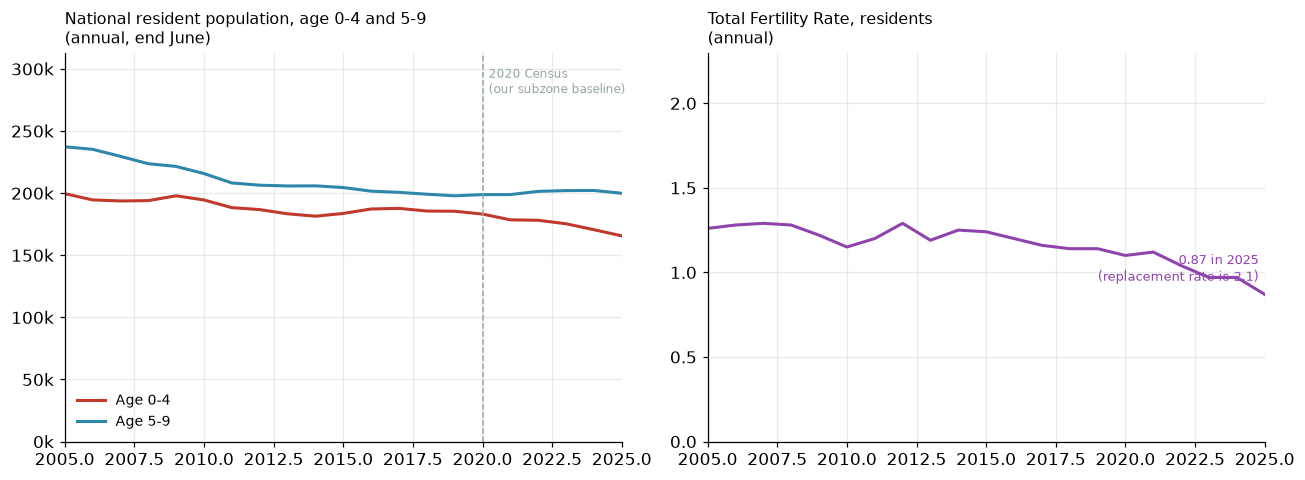

National age 0-4 population: 183,575 (2015) -> 183,076 (2020) -> 165,550 (2025)
10-year CAGR of the national 0-4 cohort: -1.03% per year -- shrinking, consistent with TFR falling from 1.24 (2015) to 0.87 (2025).


In [10]:
natl_age_raw = pd.read_csv(DATA_RAW / "SingaporeResidentsByAgeGroupEthnicGroupAndSexAtEndJuneAnnual.csv", index_col=0)
natl_age_raw.index = natl_age_raw.index.str.strip()

# The file stacks repeated age-band blocks (Total / Male / Female / by ethnic group) with
# duplicate row labels -- "Total Residents" marks the start of the first block, which is the
# one we want (both sexes, all ethnic groups).
block_end = natl_age_raw.index.get_loc("Total Male Residents")
natl_age = natl_age_raw.iloc[:block_end].T
natl_age.index = natl_age.index.astype(int)
natl_age = natl_age.sort_index()
natl_age = natl_age.rename(columns={"Total Residents": "total", "0 - 4 Years": "age_0_4", "5 - 9 Years": "age_5_9"})
natl_age = natl_age[["total", "age_0_4", "age_5_9"]].apply(pd.to_numeric)

tfr_raw = pd.read_csv(DATA_RAW / "BirthsAndFertilityRatesAnnual.csv", index_col=0)
tfr = tfr_raw.loc["Total Fertility Rate (TFR)"].astype(float)
tfr.index = tfr.index.astype(int)
tfr = tfr.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(natl_age.index, natl_age["age_0_4"], color=C_DEFICIT, label="Age 0-4", linewidth=2)
axes[0].plot(natl_age.index, natl_age["age_5_9"], color=C_SURPLUS, label="Age 5-9", linewidth=2)
axes[0].axvline(BASE_YEAR_CENSUS, color=C_NEUTRAL, linestyle="--", linewidth=1)
axes[0].annotate("2020 Census\n(our subzone baseline)", xy=(BASE_YEAR_CENSUS, 0.97), xycoords=("data", "axes fraction"),
                  fontsize=8, color=C_NEUTRAL, ha="left", va="top", xytext=(4, -2), textcoords="offset points")
axes[0].set_title("National resident population, age 0-4 and 5-9\n(annual, end June)", fontsize=10.5, loc="left")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[0].set_ylim(0, None)
axes[0].legend(frameon=False, fontsize=9, loc="lower left")
axes[0].set_xlim(2005, 2025)

axes[1].plot(tfr.index, tfr.values, color=C_HIGHLIGHT, linewidth=2)
axes[1].set_title("Total Fertility Rate, residents\n(annual)", fontsize=10.5, loc="left")
axes[1].set_xlim(2005, 2025)
axes[1].set_ylim(0, max(2.3, tfr.loc[2005:2025].max() * 1.15))
axes[1].annotate(f"{tfr.loc[2025]:.2f} in 2025\n(replacement rate is 2.1)", xy=(2025, tfr.loc[2025]),
                  fontsize=8.5, color=C_HIGHLIGHT, ha="right", va="bottom", xytext=(-4, 6), textcoords="offset points")

fig.tight_layout()
fig.savefig(OUT_CHARTS / "02_national_age_trend_and_tfr.png", bbox_inches="tight")
plt.show()

cagr_0_4 = (natl_age.loc[2025, "age_0_4"] / natl_age.loc[2015, "age_0_4"]) ** (1/10) - 1
print(f"National age 0-4 population: {natl_age.loc[2015,'age_0_4']:,.0f} (2015) -> {natl_age.loc[2020,'age_0_4']:,.0f} (2020) "
      f"-> {natl_age.loc[2025,'age_0_4']:,.0f} (2025)")
print(f"10-year CAGR of the national 0-4 cohort: {cagr_0_4:.2%} per year -- shrinking, consistent with TFR falling "
      f"from {tfr.loc[2015]:.2f} (2015) to {tfr.loc[2025]:.2f} (2025).")

The national 0-4 cohort has shrunk for a decade, tracking the TFR decline closely. That's the backdrop every subzone's local story plays out against — and our first piece of evidence for H3.

### 3.5 Subzone boundaries

The geometry for the spatial join and every map from here.

332 subzone polygons, CRS = EPSG:4326


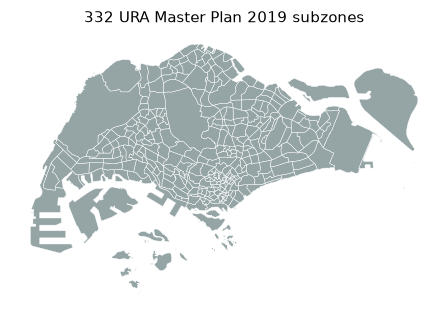

In [11]:
import geopandas as gpd

def to_title_case(s):
    # str.title() capitalises the letter *after* an apostrophe too (People'S, Monk'S) --
    # fix that so names line up exactly with the population / BTO files ("People's", "Monk's").
    s = s.str.title()
    return s.str.replace(r"(?<=')([A-Z])", lambda m: m.group(1).lower(), regex=True)

subzones_gdf = gpd.read_file(DATA_GEO / "MasterPlan2019SubzoneBoundaryNoSea.geojson")
subzones_gdf = subzones_gdf.rename(columns={"SUBZONE_N": "subzone_raw", "PLN_AREA_N": "planning_area_raw"})
subzones_gdf["subzone"] = to_title_case(subzones_gdf["subzone_raw"])
subzones_gdf["planning_area"] = to_title_case(subzones_gdf["planning_area_raw"])
subzones_gdf = subzones_gdf[["subzone", "planning_area", "geometry"]]
subzones_gdf = subzones_gdf.set_crs(epsg=4326) if subzones_gdf.crs is None else subzones_gdf

print(f"{len(subzones_gdf)} subzone polygons, CRS = {subzones_gdf.crs}")
subzones_gdf.plot(figsize=(5, 7), color=C_NEUTRAL, edgecolor="white", linewidth=0.3)
plt.title("332 URA Master Plan 2019 subzones", fontsize=10)
plt.axis("off")
plt.show()

332 subzones, the base map everything else gets painted onto. No finding here yet.

## 4. Geocoding & Spatial Join — Supply by Subzone

Centres have a postal code, not a subzone. So: (1) geocode each postal code via OneMap's free API, cached; (2) match those points to subzone boundaries.

In [12]:
import concurrent.futures as cf

GEOCODE_CACHE_PATH = DATA_CACHE / "postal_code_geocode.csv"


def geocode_postal_code(postal, retries=4, base_delay=0.8):
    """Query OneMap's free public search API. Retries with exponential backoff on any
    non-clean response (network error, non-200, throttling) -- an earlier version of this
    retried immediately with no backoff and, under concurrent load, kept re-hitting the same
    rate limit instantly, so ~75% of calls failed. A genuine "not found" (found == 0 on a
    clean 200 response) returns immediately without retrying, since retrying won't change it."""
    for attempt in range(retries):
        try:
            r = requests.get(
                "https://www.onemap.gov.sg/api/common/elastic/search",
                params={"searchVal": postal, "returnGeom": "Y", "getAddrDetails": "N", "pageNum": 1},
                timeout=10,
            )
            if r.status_code == 200:
                js = r.json()
                if js.get("found", 0) > 0:
                    res = js["results"][0]
                    return postal, float(res["LATITUDE"]), float(res["LONGITUDE"])
                return postal, None, None
        except (requests.RequestException, ValueError):
            pass
        time.sleep(base_delay * (2 ** attempt))
    return postal, None, None


postal_codes = sorted(centres["postal_code"].dropna().unique())

if GEOCODE_CACHE_PATH.exists():
    geocode_cache = pd.read_csv(GEOCODE_CACHE_PATH, dtype={"postal_code": str})
    geocode_cache["postal_code"] = geocode_cache["postal_code"].str.zfill(6)
    already_ok = set(geocode_cache.loc[geocode_cache["lat"].notna(), "postal_code"])
    missing = sorted(set(postal_codes) - already_ok)
else:
    geocode_cache = pd.DataFrame(columns=["postal_code", "lat", "lon"])
    missing = postal_codes

if missing:
    print(f"Geocoding {len(missing)} postal codes via OneMap (cached results reused for the rest; "
          "modest concurrency + backoff to stay within the anonymous rate limit)...")
    with cf.ThreadPoolExecutor(max_workers=4) as ex:
        new_results = list(ex.map(geocode_postal_code, missing))
    new_df = pd.DataFrame(new_results, columns=["postal_code", "lat", "lon"])
    geocode_cache = pd.concat(
        [geocode_cache[~geocode_cache["postal_code"].isin(new_df["postal_code"])], new_df], ignore_index=True
    )
    geocode_cache.to_csv(GEOCODE_CACHE_PATH, index=False)
else:
    print("All postal codes already cached from a previous run.")

match_rate = geocode_cache["lat"].notna().mean()
print(f"Geocoded {geocode_cache['lat'].notna().sum()} / {len(geocode_cache)} unique postal codes ({match_rate:.1%}).")

Geocoding 2 postal codes via OneMap (cached results reused for the rest; modest concurrency + backoff to stay within the anonymous rate limit)...


Geocoded 1733 / 1735 unique postal codes (99.9%).


In [13]:
childcare_centres = childcare_centres.merge(geocode_cache, on="postal_code", how="left")
geocoded_ok = childcare_centres["lat"].notna()
print(f"{geocoded_ok.sum()} / {len(childcare_centres)} childcare centres geocoded successfully "
      f"({geocoded_ok.mean():.1%}); {(~geocoded_ok).sum()} dropped from the supply model (bad/closed postal codes).")

centres_gdf = gpd.GeoDataFrame(
    childcare_centres[geocoded_ok].copy(),
    geometry=gpd.points_from_xy(childcare_centres.loc[geocoded_ok, "lon"], childcare_centres.loc[geocoded_ok, "lat"]),
    crs="EPSG:4326",
)
centres_gdf = gpd.sjoin(centres_gdf, subzones_gdf[["subzone", "planning_area", "geometry"]], how="left", predicate="within")
unmatched = centres_gdf["subzone"].isna().sum()
print(f"{unmatched} geocoded centres fell outside every subzone polygon (likely just off-coastline geocoding jitter).")

# A handful of points can land just outside a boundary edge; snap those to the nearest subzone
# rather than dropping real centres from the supply count.
if unmatched:
    unmatched_pts = centres_gdf[centres_gdf["subzone"].isna()].copy()
    nearest = gpd.sjoin_nearest(
        unmatched_pts[["centre_code", "geometry"]], subzones_gdf[["subzone", "planning_area", "geometry"]], how="left"
    )
    nearest = nearest.drop_duplicates(subset="centre_code").set_index("centre_code")
    for col in ["subzone", "planning_area"]:
        centres_gdf.loc[centres_gdf["subzone"].isna(), col] = centres_gdf.loc[centres_gdf["subzone"].isna(), "centre_code"].map(nearest[col])

print(f"After nearest-subzone snapping: {centres_gdf['subzone'].isna().sum()} centres still unmatched (dropped).")
centres_gdf = centres_gdf[centres_gdf["subzone"].notna()].copy()

1787 / 1787 childcare centres geocoded successfully (100.0%); 0 dropped from the supply model (bad/closed postal codes).
0 geocoded centres fell outside every subzone polygon (likely just off-coastline geocoding jitter).
After nearest-subzone snapping: 0 centres still unmatched (dropped).


In [14]:
supply_by_subzone = centres_gdf.groupby("subzone").agg(
    n_centres=("centre_code", "count"),
    pct_full_avg=("pct_levels_full", "mean"),
).reset_index()
supply_by_subzone["capacity"] = supply_by_subzone["n_centres"] * CAPACITY_PER_CENTRE

# Left-join onto the full 332-subzone list so zero-supply subzones stay explicit (not dropped).
subzone_list = subzones_gdf[["subzone", "planning_area"]].drop_duplicates(subset="subzone")
supply_by_subzone = subzone_list.merge(supply_by_subzone, on="subzone", how="left")
supply_by_subzone["n_centres"] = supply_by_subzone["n_centres"].fillna(0)
supply_by_subzone["capacity"] = supply_by_subzone["capacity"].fillna(0)

print(f"Total supply: {supply_by_subzone['n_centres'].sum():.0f} childcare centres -> "
      f"{supply_by_subzone['capacity'].sum():,.0f} places at the {CAPACITY_PER_CENTRE}/centre norm "
      f"(cf. actual national licensed places in 2024: {natl.loc[2024,'places']:,.0f} — same order of magnitude, "
      "a reasonable check on the norm given we're missing a small number of ungeocoded centres).")
print(f"{(supply_by_subzone['n_centres']==0).sum()} of {len(supply_by_subzone)} subzones currently have zero childcare centres.")

supply_by_subzone.sort_values("n_centres", ascending=False).head(10)[["subzone", "planning_area", "n_centres", "capacity", "pct_full_avg"]]

Total supply: 1787 childcare centres -> 178,700 places at the 100/centre norm (cf. actual national licensed places in 2024: 200,847 — same order of magnitude, a reasonable check on the norm given we're missing a small number of ungeocoded centres).
94 of 332 subzones currently have zero childcare centres.


,subzone,planning_area,n_centres,capacity,pct_full_avg
184,Tampines East,Tampines,54.0,5400.0,0.279012
269,Woodlands East,Woodlands,42.0,4200.0,0.376190
178,Tampines West,Tampines,39.0,3900.0,0.465812
94,Bedok North,Bedok,27.0,2700.0,0.264198
305,Yishun East,Yishun,25.0,2500.0,0.309333
235,Sengkang Town Centre,Sengkang,24.0,2400.0,0.183333
275,Waterway East,Punggol,24.0,2400.0,0.212500
117,Frankel,Bedok,24.0,2400.0,0.241667
238,Fernvale,Sengkang,23.0,2300.0,0.188406
256,Rivervale,Sengkang,22.0,2200.0,0.200000


### 4.4 Does the national ~80% figure hold everywhere?

No regional enrolment/capacity data exists, so we use the closest live signal instead: **share of a centre's levels showing zero vacancy right now** (`pct_levels_full`). Different question from the national ratio — not "how full," but "where are parents finding zero room today." Averaged to Planning Area, it's our best live read on regional variation.

National average share of levels marked Full: 30.1%
Across 34 planning areas with >=5 centres (small-n areas excluded as unreliable): 0% to 45%, std dev 9.8%.


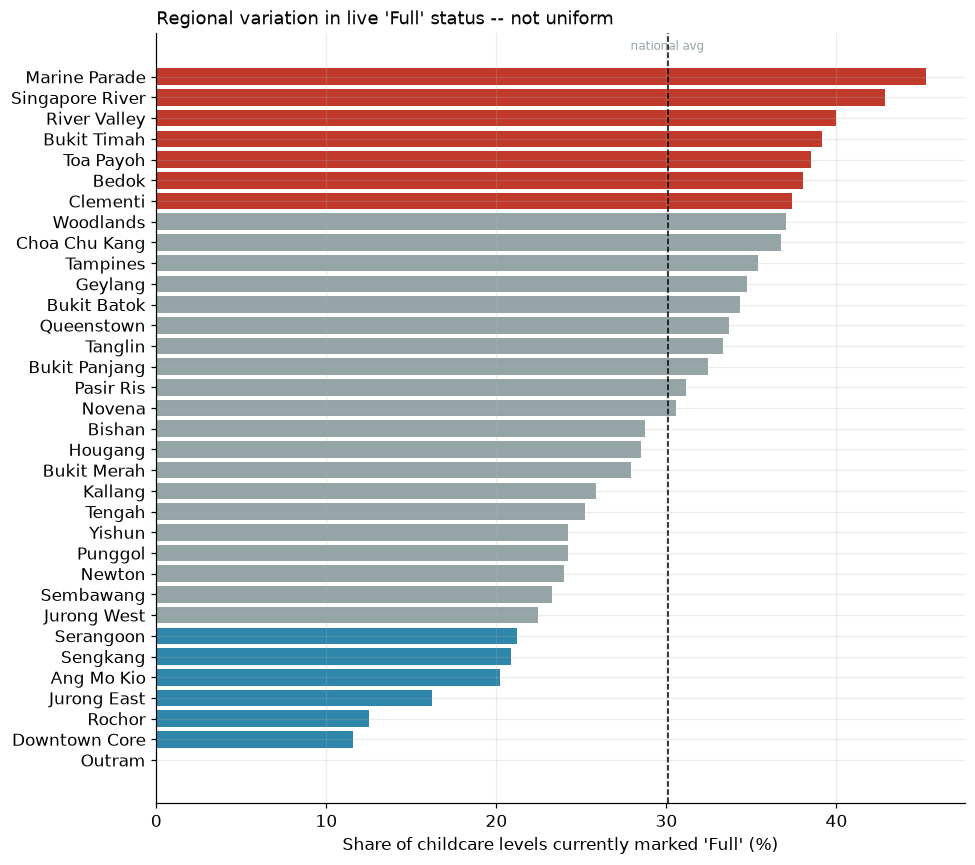

In [15]:
regional_full = centres_gdf.groupby("planning_area").agg(
    n_centres=("centre_code", "count"), pct_full_avg=("pct_levels_full", "mean")
).reset_index()
regional_reliable = regional_full[regional_full["n_centres"] >= 5].sort_values("pct_full_avg", ascending=False)

print(f"National average share of levels marked Full: {centres_gdf['pct_levels_full'].mean():.1%}")
print(f"Across {len(regional_reliable)} planning areas with >=5 centres (small-n areas excluded as unreliable): "
      f"{regional_reliable['pct_full_avg'].min():.0%} to {regional_reliable['pct_full_avg'].max():.0%}, "
      f"std dev {regional_reliable['pct_full_avg'].std():.1%}.")

fig, ax = plt.subplots(figsize=(9, 8))
colors = [C_DEFICIT if v >= regional_reliable["pct_full_avg"].quantile(0.8) else
          (C_SURPLUS if v <= regional_reliable["pct_full_avg"].quantile(0.2) else C_NEUTRAL)
          for v in regional_reliable["pct_full_avg"]]
ax.barh(regional_reliable["planning_area"], regional_reliable["pct_full_avg"] * 100, color=colors)
ax.invert_yaxis()
ax.axvline(centres_gdf["pct_levels_full"].mean() * 100, color="black", linestyle="--", linewidth=1)
ax.text(centres_gdf["pct_levels_full"].mean() * 100, -1.3, "national avg", fontsize=8, ha="center", color=C_NEUTRAL)
ax.set_xlabel("Share of childcare levels currently marked 'Full' (%)")
ax.set_title("Regional variation in live 'Full' status -- not uniform", fontsize=12, loc="left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "12_regional_fullness.png", bbox_inches="tight")
plt.show()

**No, it doesn't hold everywhere — and not how you'd guess.** Tightest: Marine Parade, Singapore River, River Valley, Bukit Timah, Toa Payoh — mature, central estates, *not* the BTO growth towns leading the demand-model list. Loosest: Outram, Downtown Core, Rochor, Jurong East, Ang Mo Kio.

Not a contradiction — Section 7.1 finds the same weak link (r=0.035) between modelled gap and live vacancy. Two different things: our model tracks where *population* is outrunning supply. Live "Full" status tracks which *specific centres* are oversubscribed. Both matter, differently.

## 5. Forecast Modelling

Four building blocks turn the 2020 Census into a 2026-2031 demand number. The diagram is the map; 5.1-5.4 below are the detail.

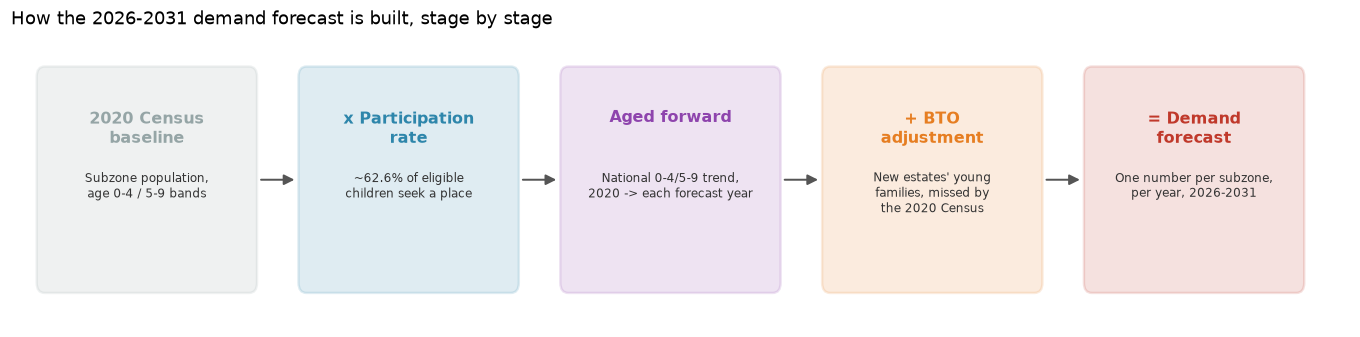

In [16]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12.5, 3.2))
stages = [
    ("2020 Census\nbaseline", "Subzone population,\nage 0-4 / 5-9 bands", C_NEUTRAL),
    ("x Participation\nrate", "~62.6% of eligible\nchildren seek a place", C_SURPLUS),
    ("Aged forward", "National 0-4/5-9 trend,\n2020 -> each forecast year", C_HIGHLIGHT),
    ("+ BTO\nadjustment", "New estates\' young\nfamilies, missed by\nthe 2020 Census", C_BTO),
    ("= Demand\nforecast", "One number per subzone,\nper year, 2026-2031", C_DEFICIT),
]
n = len(stages)
box_w, box_h, gap = 2.15, 1.7, 0.5
x0 = 0.3
for i, (title, desc, color) in enumerate(stages):
    x = x0 + i * (box_w + gap)
    box = FancyBboxPatch((x, 0.3), box_w, box_h, boxstyle="round,pad=0.04,rounding_size=0.08",
                          facecolor=color, alpha=0.15, edgecolor=color, linewidth=1.6)
    ax.add_patch(box)
    ax.text(x + box_w / 2, 0.3 + box_h - 0.30, title, ha="center", va="top", fontsize=10.5, fontweight="bold", color=color)
    ax.text(x + box_w / 2, 0.3 + box_h - 0.78, desc, ha="center", va="top", fontsize=8, color="#333333")
    if i < n - 1:
        arrow = FancyArrowPatch((x + box_w + 0.05, 0.3 + box_h / 2), (x + box_w + gap - 0.05, 0.3 + box_h / 2),
                                 arrowstyle="-|>", mutation_scale=14, color="#555555", linewidth=1.3)
        ax.add_patch(arrow)

ax.set_xlim(0, x0 + n * (box_w + gap))
ax.set_ylim(0, 2.3)
ax.axis("off")
ax.set_title("How the 2026-2031 demand forecast is built, stage by stage", fontsize=12, loc="left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "14_forecast_model_structure.png", bbox_inches="tight")
plt.show()

Each box is a deliberate choice, not a default. Baseline x participation rate = 2020 demand. Aged forward = each forecast year, national trend. + BTO = local correction the national trend can't see. Output: one demand number per subzone per year, compared against supply in Section 6.

### 5.1 Baseline: 5-year age bands to 18mo-6y

Census only gives `0-4` and `5-9`. Assume ages spread evenly within each band:
- 18mo-4y = 3.5 of 5 years in `0-4` -> weight **0.70**
- 5-6y = 2 of 5 years in `5-9` -> weight **0.40**

### 5.2 From eligible population to real demand

Population in that age band is a ceiling, not real demand — plenty of families use informal care instead. We compute a national **participation rate** (eligible population vs. actual enrolment, 2020) and apply it to every subzone evenly. A simplification — Section 10 flags it.

In [17]:
pop_subzone["eligible_2020"] = BAND_WEIGHT_0_4 * pop_subzone["Total_0_4"] + BAND_WEIGHT_5_9 * pop_subzone["Total_5_9"]

national_eligible_2020 = BAND_WEIGHT_0_4 * natl_age.loc[BASE_YEAR_CENSUS, "age_0_4"] + BAND_WEIGHT_5_9 * natl_age.loc[BASE_YEAR_CENSUS, "age_5_9"]
PARTICIPATION_RATE = natl.loc[BASE_YEAR_CENSUS, "enrolment"] / national_eligible_2020

print(f"National 18mo-6y eligible population (2020, modelled): {national_eligible_2020:,.0f}")
print(f"National childcare enrolment (2020, actual): {natl.loc[BASE_YEAR_CENSUS,'enrolment']:,.0f}")
print(f"Implied participation rate: {PARTICIPATION_RATE:.1%} -- this is the fraction of eligible children "
      "we assume actually seek a centre-based place, applied to every subzone.")

pop_subzone["demand_2020"] = pop_subzone["eligible_2020"] * PARTICIPATION_RATE
pop_subzone[["planning_area", "subzone", "Total_0_4", "Total_5_9", "eligible_2020", "demand_2020"]].sort_values("demand_2020", ascending=False).head(8)

National 18mo-6y eligible population (2020, modelled): 207,648
National childcare enrolment (2020, actual): 130,062
Implied participation rate: 62.6% -- this is the fraction of eligible children we assume actually seek a centre-based place, applied to every subzone.


,planning_area,subzone,Total_0_4,Total_5_9,eligible_2020,demand_2020
276,Tampines,Tampines East,5390,5400,5933.0,3716.182414
202,Punggol,Waterway East,5470,4930,5801.0,3633.503150
197,Punggol,Matilda,5430,4850,5741.0,3595.921666
319,Woodlands,Woodlands East,4960,5280,5584.0,3497.583449
248,Sengkang,Fernvale,4830,5270,5489.0,3438.079433
329,Yishun,Yishun East,4270,4410,4753.0,2977.079895
246,Sengkang,Anchorvale,3790,3850,4193.0,2626.319377
278,Tampines,Tampines West,3790,3780,4165.0,2608.781351


### 5.3 Ageing the baseline forward

No subzone-level annual data, so every subzone grows/shrinks at the national 0-4/5-9 rate. 2020-2025 is observed; 2026 onward extrapolates that trend.

What makes a subzone deviate from this? A local shock — new BTO flats. Next.

In [18]:
LATEST_ACTUAL_YEAR = 2025
cagr_recent_0_4 = (natl_age.loc[LATEST_ACTUAL_YEAR, "age_0_4"] / natl_age.loc[BASE_YEAR_CENSUS, "age_0_4"]) ** (1 / (LATEST_ACTUAL_YEAR - BASE_YEAR_CENSUS)) - 1
cagr_recent_5_9 = (natl_age.loc[LATEST_ACTUAL_YEAR, "age_5_9"] / natl_age.loc[BASE_YEAR_CENSUS, "age_5_9"]) ** (1 / (LATEST_ACTUAL_YEAR - BASE_YEAR_CENSUS)) - 1
print(f"Observed 2020-2025 CAGR: age 0-4 = {cagr_recent_0_4:.2%}/yr, age 5-9 = {cagr_recent_5_9:.2%}/yr")

growth_factor = {}
for y in FORECAST_YEARS:
    if y <= LATEST_ACTUAL_YEAR:
        f_0_4 = natl_age.loc[y, "age_0_4"] / natl_age.loc[BASE_YEAR_CENSUS, "age_0_4"]
        f_5_9 = natl_age.loc[y, "age_5_9"] / natl_age.loc[BASE_YEAR_CENSUS, "age_5_9"]
    else:
        base_ratio_0_4 = natl_age.loc[LATEST_ACTUAL_YEAR, "age_0_4"] / natl_age.loc[BASE_YEAR_CENSUS, "age_0_4"]
        base_ratio_5_9 = natl_age.loc[LATEST_ACTUAL_YEAR, "age_5_9"] / natl_age.loc[BASE_YEAR_CENSUS, "age_5_9"]
        f_0_4 = base_ratio_0_4 * (1 + cagr_recent_0_4) ** (y - LATEST_ACTUAL_YEAR)
        f_5_9 = base_ratio_5_9 * (1 + cagr_recent_5_9) ** (y - LATEST_ACTUAL_YEAR)
    growth_factor[y] = {"factor_0_4": f_0_4, "factor_5_9": f_5_9}

growth_factor_df = pd.DataFrame(growth_factor).T
growth_factor_df.index.name = "year"
print("\nGrowth factor relative to 2020 (applied to each subzone's 2020 baseline):")
growth_factor_df.round(3)

Observed 2020-2025 CAGR: age 0-4 = -1.99%/yr, age 5-9 = 0.11%/yr

Growth factor relative to 2020 (applied to each subzone's 2020 baseline):


,factor_0_4,factor_5_9
year,,
2026,0.886,1.007
2027,0.869,1.008
2028,0.851,1.009
2029,0.834,1.010
2030,0.818,1.011
2031,0.801,1.012


In [19]:
pop_indexed = pop_subzone.set_index("subzone")
organic_demand = pd.DataFrame(index=pop_indexed.index)
for y in FORECAST_YEARS:
    gf = growth_factor_df.loc[y]
    organic_demand[y] = (
        BAND_WEIGHT_0_4 * pop_indexed["Total_0_4"] * gf["factor_0_4"]
        + BAND_WEIGHT_5_9 * pop_indexed["Total_5_9"] * gf["factor_5_9"]
    ) * PARTICIPATION_RATE

print("Organic demand (national trend only, no BTO adjustment yet), national total by year:")
print(organic_demand.sum().round(0).astype(int))

Organic demand (national trend only, no BTO adjustment yet), national total by year:
2026    121253
2027    119889
2028    118554
2029    117247
2030    115966
2031    114713
dtype: int64


### 5.4 The BTO adjustment

New estates draw young families the 2020 Census couldn't see (anything completing after 2020). So: **0.28 kids per unit** (derived in 3.2), half-weighted in the completion year, full weight the year after, held flat.

Section 7.2 stress-tests this +/-50% — the assumption we'd most want real HDB occupancy data to fix.

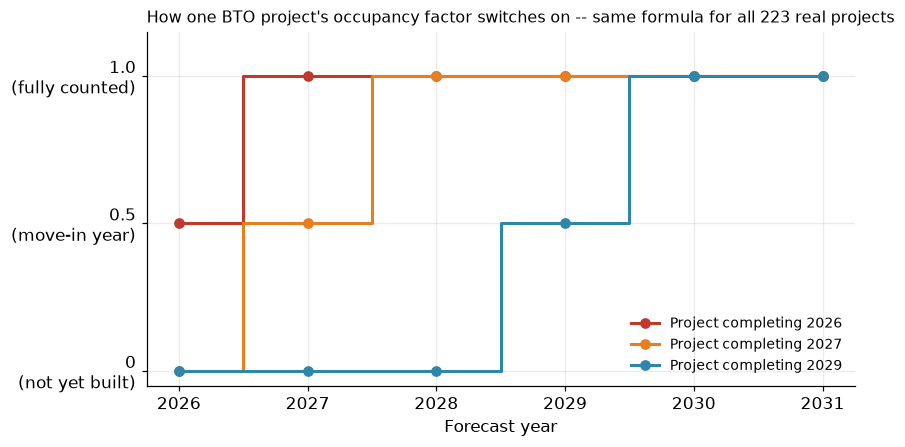

In [20]:
example_years = [2026, 2027, 2029]
example_labels = [f"Project completing {y}" for y in example_years]
example_colors = [C_DEFICIT, C_BTO, C_SURPLUS]

fig, ax = plt.subplots(figsize=(8, 4.2))
for y, label, color in zip(example_years, example_labels, example_colors):
    factors = [0.0 if fy < y else (0.5 if fy == y else 1.0) for fy in FORECAST_YEARS]
    ax.step(FORECAST_YEARS, factors, where="mid", marker="o", markersize=6, linewidth=2, label=label, color=color)
ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0\n(not yet built)", "0.5\n(move-in year)", "1.0\n(fully counted)"])
ax.set_xlabel("Forecast year")
ax.set_title("How one BTO project\'s occupancy factor switches on -- same formula for all 223 real projects", fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "16_bto_occupancy_mechanism.png", bbox_inches="tight")
plt.show()

Three example projects, different completion years. A 2029 project: 0 kids before 2029, half its estimate in 2029, full from 2030 — gradual move-in, not instant. All 223 real BTO projects get this same treatment, summed per subzone per year into `bto_demand`.

In [21]:
def compute_bto_demand(yield_per_unit=CHILD_YIELD_PER_BTO_UNIT):
    bto_valid = bto.dropna(subset=["completion_year", "subzone"]).copy()
    bto_valid["completion_year"] = bto_valid["completion_year"].astype(int)
    cols = {}
    for y in FORECAST_YEARS:
        active = bto_valid[bto_valid["completion_year"] <= y].copy()
        active["occ_factor"] = np.where(active["completion_year"] == y, 0.5, 1.0)
        active["contribution"] = active["units"] * yield_per_unit * active["occ_factor"]
        cols[y] = active.groupby("subzone")["contribution"].sum()
    out = pd.DataFrame(cols)
    return out.reindex(pop_indexed.index).fillna(0.0)

bto_demand = compute_bto_demand()
print(f"BTO-driven demand, national total by year (children):")
print(bto_demand.sum().round(0).astype(int))
print(f"\nTop 5 subzones by 2031 BTO-driven demand:")
bto_demand[FORECAST_YEARS[-1]].sort_values(ascending=False).head()

BTO-driven demand, national total by year (children):
2026    36447
2027    41560
2028    46546
2029    50091
2030    51313
2031    51313
dtype: int64

Top 5 subzones by 2031 BTO-driven demand:


subzone
Brickworks        3272.92
Tampines North    3227.84
Northshore        2954.28
Yishun East       2303.28
Plantation        2258.76
Name: 2031, dtype: float64

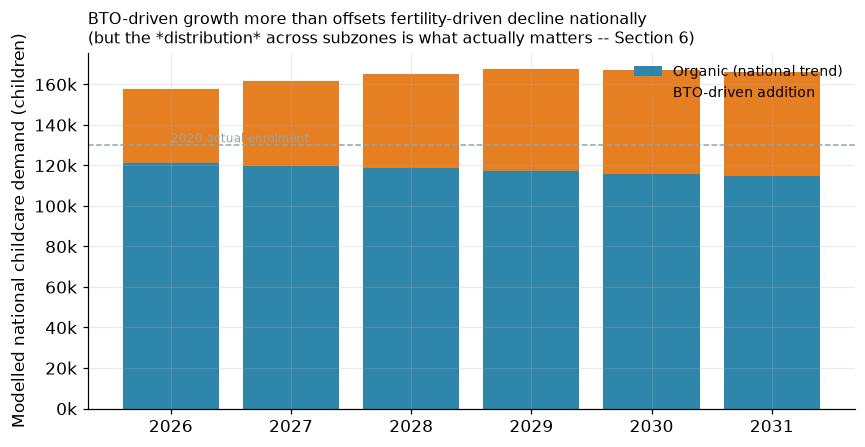

Total modelled demand: 157,699 (2026) -> 166,025 (2031), a +5.3% change.
Note the BTO-driven bars flatten in 2030-2031: btomapping.csv only has confirmed completions through 2029, so no *new* projects add to modelled demand after that -- a data-coverage artefact, not a real slowdown in housing supply (flagged again in Section 10).


In [22]:
total_demand = organic_demand + bto_demand  # subzone x forecast year

fig, ax = plt.subplots(figsize=(8, 4.2))
organic_natl = organic_demand.sum()
bto_natl = bto_demand.sum()
ax.bar(FORECAST_YEARS, organic_natl, label="Organic (national trend)", color=C_SURPLUS)
ax.bar(FORECAST_YEARS, bto_natl, bottom=organic_natl, label="BTO-driven addition", color=C_BTO)
ax.axhline(natl.loc[BASE_YEAR_CENSUS, "enrolment"], color=C_NEUTRAL, linestyle="--", linewidth=1)
ax.text(FORECAST_YEARS[0], natl.loc[BASE_YEAR_CENSUS, "enrolment"] * 1.01, "2020 actual enrolment", fontsize=8, color=C_NEUTRAL)
ax.set_ylabel("Modelled national childcare demand (children)")
ax.set_title("BTO-driven growth more than offsets fertility-driven decline nationally\n(but the *distribution* across subzones is what actually matters -- Section 6)", fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
fig.tight_layout()
fig.savefig(OUT_CHARTS / "03_national_demand_forecast_organic_vs_bto.png", bbox_inches="tight")
plt.show()

pct_change = total_demand[FORECAST_YEARS[-1]].sum() / total_demand[FORECAST_YEARS[0]].sum() - 1
print(f"Total modelled demand: {total_demand[FORECAST_YEARS[0]].sum():,.0f} ({FORECAST_YEARS[0]}) -> "
      f"{total_demand[FORECAST_YEARS[-1]].sum():,.0f} ({FORECAST_YEARS[-1]}), a {pct_change:+.1%} change.")
print("Note the BTO-driven bars flatten in 2030-2031: btomapping.csv only has confirmed completions "
      "through 2029, so no *new* projects add to modelled demand after that -- a data-coverage artefact, "
      "not a real slowdown in housing supply (flagged again in Section 10).")

Nationally, BTO growth outweighs the fertility decline — demand rises a modest ~5% over the forecast. **That's exactly why a national number is the wrong number to manage this with** — it hides subzones growing fast and shrinking side by side. Everything from here works at subzone level.

## 6. Gap Analysis & Prioritisation

Supply held at today's level — no assumed future centres, since that's ECDA's decision to make. First, reconcile subzone names across the three data sources.

In [23]:
subzone_master = subzones_gdf[["subzone", "planning_area"]].drop_duplicates(subset="subzone").set_index("subzone")

demand_idx, geo_idx = set(total_demand.index), set(subzone_master.index)
print(f"Demand subzones not on the boundary list (dropped, no geometry to map them with): {sorted(demand_idx - geo_idx)}")
print(f"Boundary subzones with no Census demand row (assumed 0 -- typically parks/reservoirs/industrial land): "
      f"{len(geo_idx - demand_idx)}")

gap_table = subzone_master.copy()
gap_table["supply"] = supply_by_subzone.set_index("subzone")["capacity"].reindex(subzone_master.index).fillna(0)
gap_table["n_centres"] = supply_by_subzone.set_index("subzone")["n_centres"].reindex(subzone_master.index).fillna(0)
gap_table["pct_full_avg"] = supply_by_subzone.set_index("subzone")["pct_full_avg"].reindex(subzone_master.index)

for y in FORECAST_YEARS:
    gap_table[f"demand_{y}"] = total_demand[y].reindex(subzone_master.index).fillna(0)
    gap_table[f"organic_{y}"] = organic_demand[y].reindex(subzone_master.index).fillna(0)
    gap_table[f"bto_{y}"] = bto_demand[y].reindex(subzone_master.index).fillna(0)
    gap_table[f"gap_{y}"] = gap_table[f"demand_{y}"] - gap_table["supply"]

gap_table["gap_trend"] = gap_table[f"gap_{FORECAST_YEARS[-1]}"] - gap_table[f"gap_{FORECAST_YEARS[0]}"]
gap_table["centres_needed_2031"] = np.ceil(gap_table[f"gap_{FORECAST_YEARS[-1]}"].clip(lower=0) / CAPACITY_PER_CENTRE)

print(f"\n{len(gap_table)} subzones in the final gap table.")
gap_table[["planning_area", "supply", f"demand_{FORECAST_YEARS[0]}", f"gap_{FORECAST_YEARS[0]}", f"gap_{FORECAST_YEARS[-1]}"]].describe().round(0)

Demand subzones not on the boundary list (dropped, no geometry to map them with): []
Boundary subzones with no Census demand row (assumed 0 -- typically parks/reservoirs/industrial land): 0



332 subzones in the final gap table.


,supply,demand_2026,gap_2026,gap_2031
count,332.0,332.0,332.0,332.0
mean,538.0,475.0,-63.0,-38.0
std,698.0,812.0,475.0,500.0
min,0.0,0.0,-1906.0,-2062.0
25%,0.0,0.0,-217.0,-207.0
50%,300.0,137.0,-54.0,-9.0
75%,800.0,602.0,0.0,7.0
max,5400.0,5075.0,3073.0,3329.0


### 6.1 The map: today vs. five years out

The single most important exhibit here. Same colour scale both maps — red deficit, blue surplus — directly comparable.

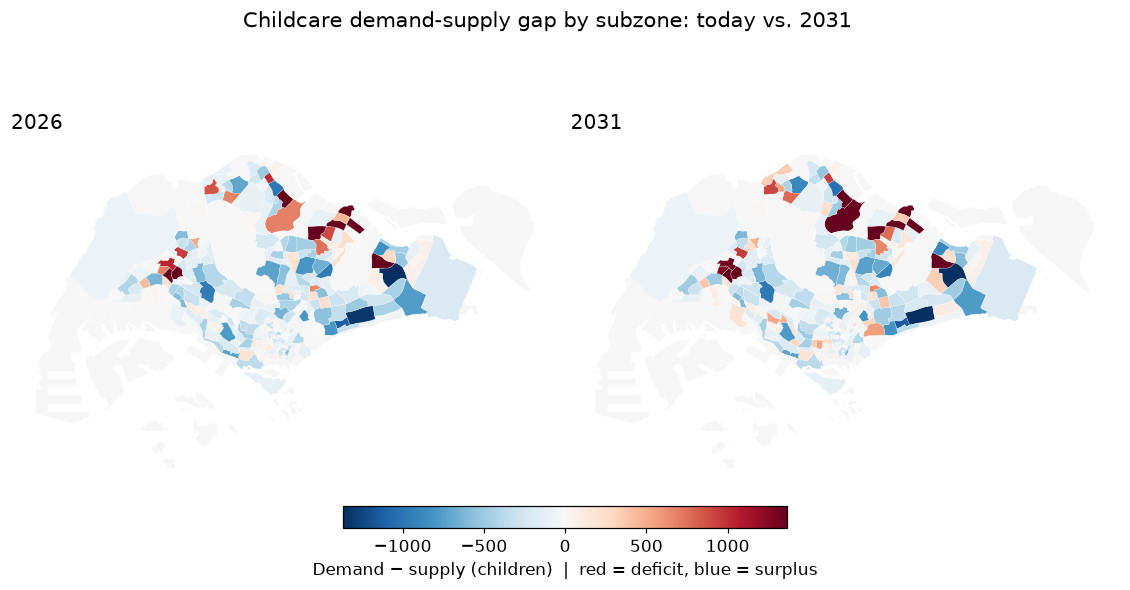

In [24]:
from matplotlib.colors import TwoSlopeNorm

plot_gdf = subzones_gdf.merge(gap_table, left_on="subzone", right_index=True, how="left")
vmax = max(plot_gdf[f"gap_{FORECAST_YEARS[0]}"].abs().quantile(0.97), plot_gdf[f"gap_{FORECAST_YEARS[-1]}"].abs().quantile(0.97))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ax, y in zip(axes, [FORECAST_YEARS[0], FORECAST_YEARS[-1]]):
    plot_gdf.plot(column=f"gap_{y}", ax=ax, cmap="RdBu_r", norm=norm, edgecolor="white", linewidth=0.15)
    ax.set_title(f"{y}", fontsize=13, loc="left")
    ax.axis("off")

fig.subplots_adjust(top=0.86, bottom=0.14, wspace=0.02)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.03, shrink=0.45)
cbar.set_label("Demand \u2212 supply (children)  |  red = deficit, blue = surplus")
fig.suptitle("Childcare demand-supply gap by subzone: today vs. 2031", fontsize=14, y=0.98)
fig.savefig(OUT_CHARTS / "04_gap_maps_2026_vs_2031.png", bbox_inches="tight")
plt.show()

**Reading it:** even in 2026, red patches are scattered, not one big shortage zone. By 2031 some deepen (new BTO towns), some turn blue (fading demand in older estates). Side by side, the clearest evidence for H1: scattered and spatial, not one uniform national problem.

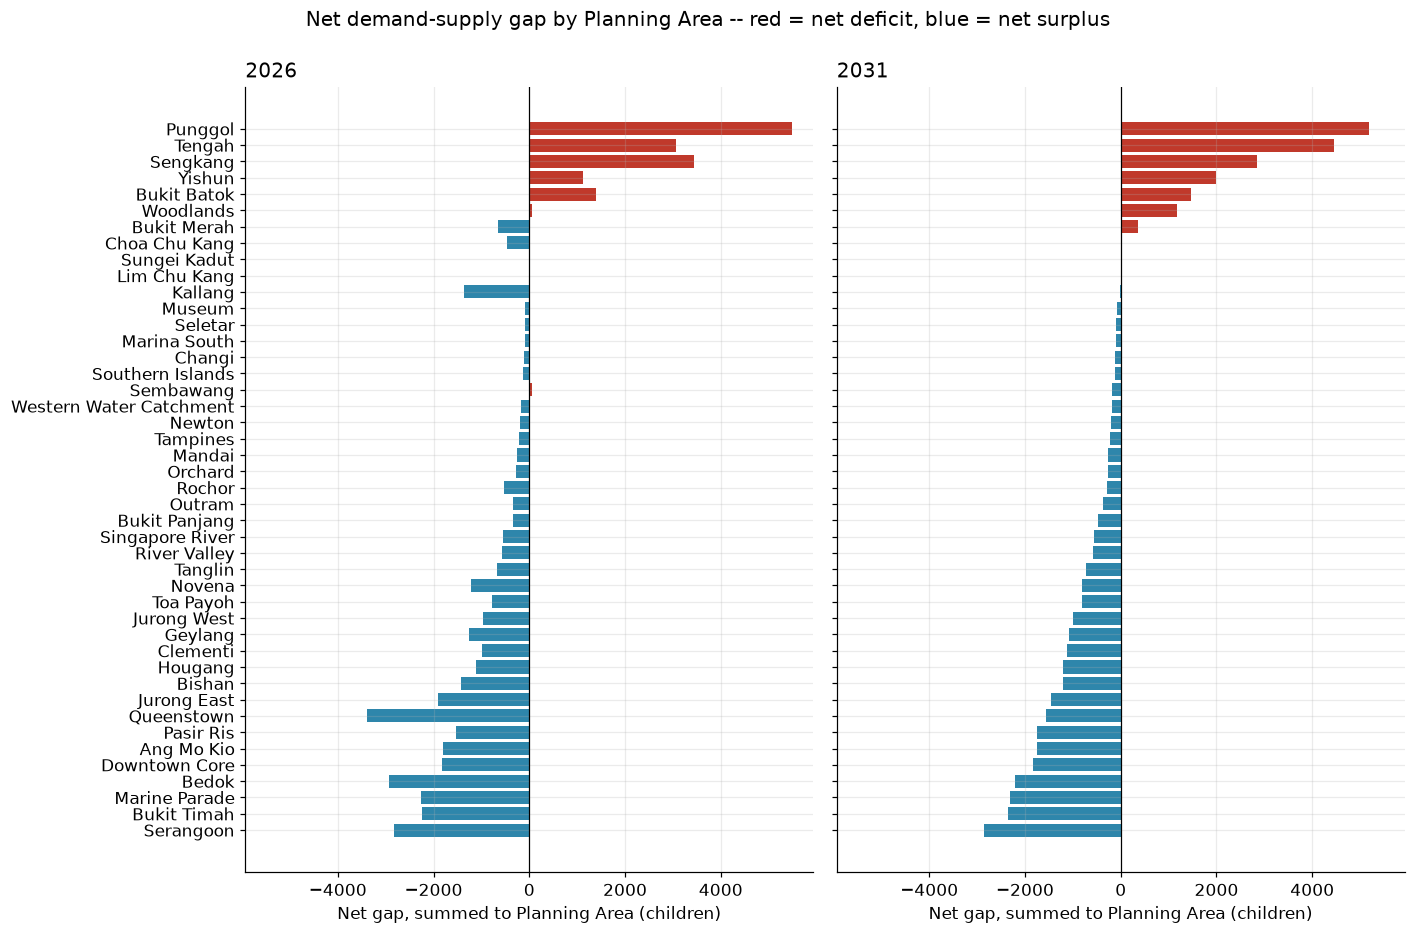

44 populated Planning Areas. 10 are in net deficit by 2031.
Biggest net deficit, 2031: Punggol (5,182 children).
Biggest net surplus, 2031: Serangoon (-2,852 children).


In [25]:
planning_gap_2026 = gap_table.groupby("planning_area")[f"gap_{FORECAST_YEARS[0]}"].sum()
planning_gap_2031 = gap_table.groupby("planning_area")[f"gap_{FORECAST_YEARS[-1]}"].sum()

# Drop Planning Areas with no residential population and no centres at all (industrial /
# reserve / reclamation land like Tuas, Western Islands, Straits View) -- their gap is
# exactly 0 because there is nothing to compare, not because they are genuinely balanced.
has_activity = (gap_table.groupby("planning_area")[f"demand_{FORECAST_YEARS[-1]}"].sum()
                + gap_table.groupby("planning_area")["supply"].sum()) > 1
planning_gap_2026 = planning_gap_2026[has_activity]
planning_gap_2031 = planning_gap_2031[has_activity]

order = planning_gap_2031.sort_values().index
vmax = max(planning_gap_2026.abs().max(), planning_gap_2031.abs().max())

fig, axes = plt.subplots(1, 2, figsize=(13, 8.5), sharey=True)
for ax, series, y in zip(axes, [planning_gap_2026.reindex(order), planning_gap_2031.reindex(order)], [FORECAST_YEARS[0], FORECAST_YEARS[-1]]):
    colors = [C_DEFICIT if v > 0 else C_SURPLUS for v in series.values]
    ax.barh(series.index, series.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-vmax * 1.08, vmax * 1.08)
    ax.set_title(f"{y}", fontsize=13, loc="left")
    ax.set_xlabel("Net gap, summed to Planning Area (children)")

fig.suptitle("Net demand-supply gap by Planning Area -- red = net deficit, blue = net surplus", fontsize=13, y=0.995)
fig.tight_layout()
fig.savefig(OUT_CHARTS / "18_gap_by_planning_area.png", bbox_inches="tight")
plt.show()

n_areas = len(planning_gap_2031)
n_deficit_areas_2031 = (planning_gap_2031 > 0).sum()
top_deficit_area = planning_gap_2031.idxmax()
top_surplus_area = planning_gap_2031.idxmin()
print(f"{n_areas} populated Planning Areas. {n_deficit_areas_2031} are in net deficit by {FORECAST_YEARS[-1]}.")
print(f"Biggest net deficit, {FORECAST_YEARS[-1]}: {top_deficit_area} ({planning_gap_2031[top_deficit_area]:,.0f} children).")
print(f"Biggest net surplus, {FORECAST_YEARS[-1]}: {top_surplus_area} ({planning_gap_2031[top_surplus_area]:,.0f} children).")

### 6.1b Same picture, by name

Same numbers, summed to the ~55 named Planning Areas instead of 332 unlabeled polygons.

Only **10 of 44 populated areas** are in net deficit by 2031 — far fewer than the 89 subzones in Section 6.2's histogram, because summing cancels out subzone-level dispersion. Same H1 point, different zoom level: an area can look fine net while hiding a genuinely short subzone — why Section 6.4's list stays at subzone level.

Punggol: biggest net deficit (5,182 kids). Serangoon: biggest net surplus (-2,852).

### 6.2 How dispersed is this, really?

A number on what the map shows: how wide is the spread, given the national picture looks fine?

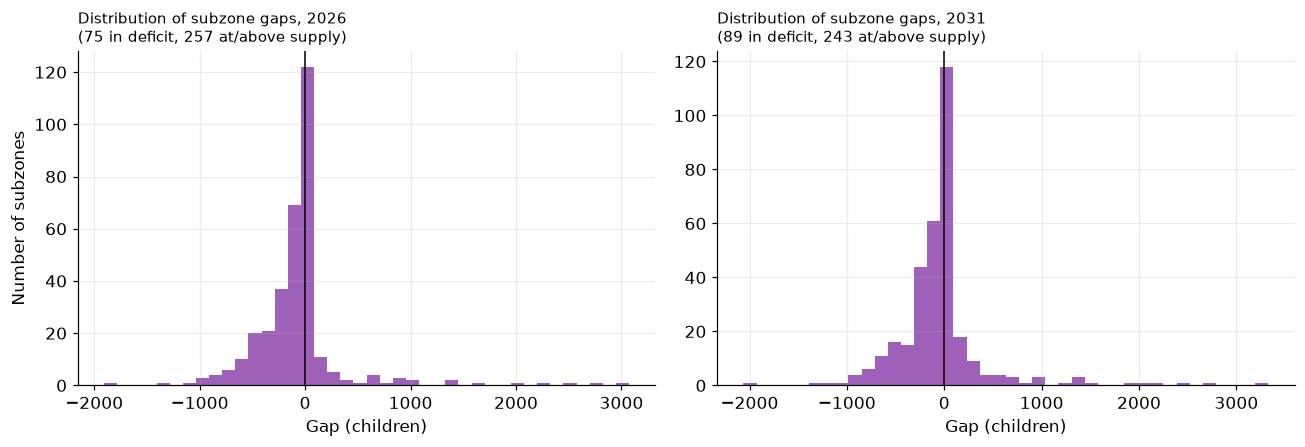

23% of subzones are in deficit today, even though national utilisation sits well under 100%.
Gap range in 2026: -1,906 (biggest surplus) to 3,073 (biggest deficit) children.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, y, label in zip(axes, [FORECAST_YEARS[0], FORECAST_YEARS[-1]], ["2026", "2031"]):
    vals = gap_table[f"gap_{y}"]
    ax.hist(vals, bins=40, color=C_HIGHLIGHT, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Distribution of subzone gaps, {label}\n({(vals>0).sum()} in deficit, {(vals<=0).sum()} at/above supply)", fontsize=10, loc="left")
    ax.set_xlabel("Gap (children)")
ax.set_ylabel("")
axes[0].set_ylabel("Number of subzones")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "05_gap_dispersion_histograms.png", bbox_inches="tight")
plt.show()

deficit_share_2026 = (gap_table[f"gap_{FORECAST_YEARS[0]}"] > 0).mean()
print(f"{deficit_share_2026:.0%} of subzones are in deficit today, even though national utilisation sits well under 100%.")
print(f"Gap range in 2026: {gap_table[f'gap_{FORECAST_YEARS[0]}'].min():,.0f} (biggest surplus) to "
      f"{gap_table[f'gap_{FORECAST_YEARS[0]}'].max():,.0f} (biggest deficit) children.")

**Reading it:** both years show a wide spread straddling zero — not clustered near a small number. A comfortable national average is fully consistent with subzones deep in deficit and deep in surplus at once. 2031 isn't a different shape from 2026 — the change is mostly at the tails.

### 6.3 Four kinds of subzone

Every subzone falls into one of four groups based on today vs. 2031. This split becomes ECDA's build/relocate list.

category
Comfortable                  196
Urgent: deficit today         75
Relocation candidate          43
Emerging: deficit by 2031     18
Name: count, dtype: int64


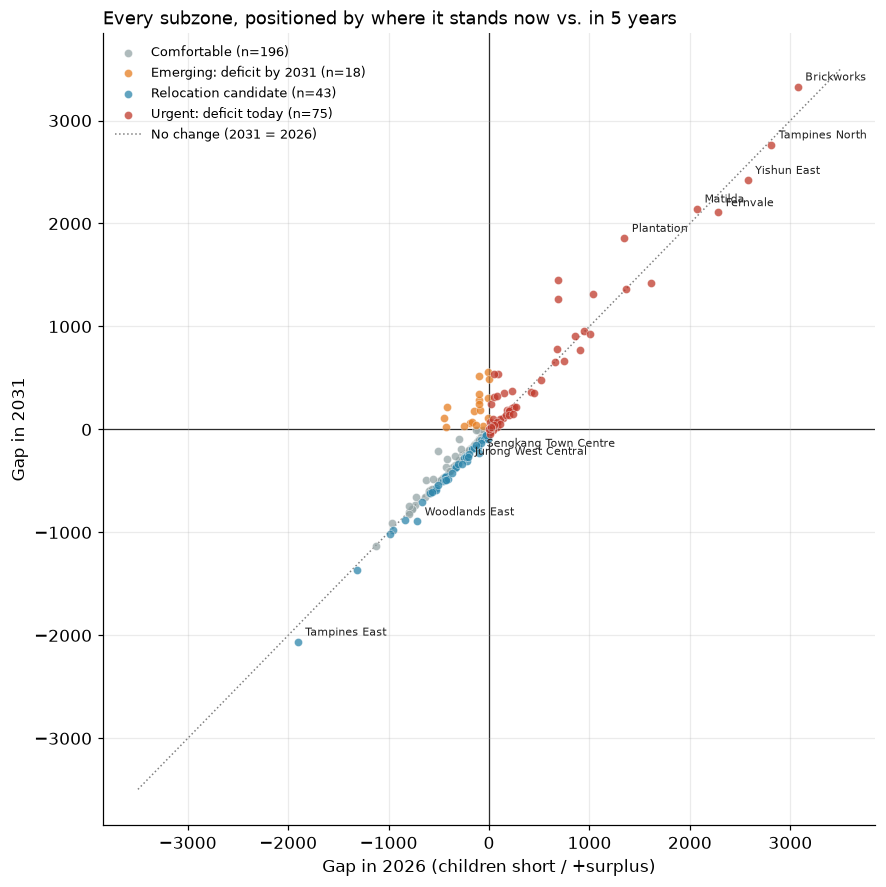

In [27]:
RELOCATION_SURPLUS_THRESHOLD = -20  # gap_trend more negative than this = surplus meaningfully growing

def categorize(row):
    if row[f"gap_{FORECAST_YEARS[0]}"] > 0:
        return "Urgent: deficit today"
    elif row[f"gap_{FORECAST_YEARS[-1]}"] > 0:
        return "Emerging: deficit by 2031"
    elif row["gap_trend"] < RELOCATION_SURPLUS_THRESHOLD:
        return "Relocation candidate"
    else:
        return "Comfortable"

gap_table["category"] = gap_table.apply(categorize, axis=1)
print(gap_table["category"].value_counts())

colors = {"Urgent: deficit today": C_DEFICIT, "Emerging: deficit by 2031": C_BTO,
          "Relocation candidate": C_SURPLUS, "Comfortable": C_NEUTRAL}

fig, ax = plt.subplots(figsize=(8.2, 8.2))
for cat, sub in gap_table.groupby("category"):
    ax.scatter(sub[f"gap_{FORECAST_YEARS[0]}"], sub[f"gap_{FORECAST_YEARS[-1]}"], s=28, alpha=0.75,
               label=f"{cat} (n={len(sub)})", color=colors[cat], edgecolor="white", linewidth=0.3)
lim = max(gap_table[f"gap_{FORECAST_YEARS[0]}"].abs().max(), gap_table[f"gap_{FORECAST_YEARS[-1]}"].abs().max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], color="grey", linestyle=":", linewidth=1, label="No change (2031 = 2026)", zorder=0)
ax.axhline(0, color="black", linewidth=0.8, zorder=0)
ax.axvline(0, color="black", linewidth=0.8, zorder=0)
ax.set_xlabel(f"Gap in {FORECAST_YEARS[0]} (children short / +surplus)")
ax.set_ylabel(f"Gap in {FORECAST_YEARS[-1]}")
ax.set_title("Every subzone, positioned by where it stands now vs. in 5 years", fontsize=11.5, loc="left")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")

# Label the subzones that matter most: the worst Urgent cases (the ones Section 6.4 leads
# with) and the fastest-growing Relocation candidates -- not all 332 points, just the ones
# a reader would actually want named.
top_urgent = gap_table[gap_table["category"] == "Urgent: deficit today"].nlargest(6, f"gap_{FORECAST_YEARS[-1]}")
top_reloc = gap_table[gap_table["category"] == "Relocation candidate"].nsmallest(4, "gap_trend")
for name, row in pd.concat([top_urgent, top_reloc]).iterrows():
    ax.annotate(name, (row[f"gap_{FORECAST_YEARS[0]}"], row[f"gap_{FORECAST_YEARS[-1]}"]),
                fontsize=7.5, xytext=(5, 4), textcoords="offset points", color="#222222")

fig.tight_layout()
fig.savefig(OUT_CHARTS / "06_gap_quadrant_2026_vs_2031.png", bbox_inches="tight")
plt.show()

**Reading it:** x-axis = today's gap, y-axis = 2031's. Above the dotted line = getting worse. Red (deficit today) clusters upper-right — mostly staying short or worsening. Green (relocation candidates) sits lower-left, drifting further into surplus. Orange (emerging) is the one to watch: fine today, short by 2031, almost all BTO-driven.

### 6.4 The two lists ECDA asked for

**List 1 -- build/relocate priority.** Ranked by 2031 shortfall, converted to centre count.

BTO share tells you *why* each subzone is short. Plantation, Park, Garden (all Tengah) are **100% BTO-driven** -- brand new town, every bit of the shortage is new housing. Matilda (Punggol) is the opposite -- only **11%** BTO-driven, so most of its shortage is the population already there, not new blocks. Same rank on the list, different problem to solve.

In [28]:
gap_table["bto_share_2031"] = (gap_table[f"bto_{FORECAST_YEARS[-1]}"] / gap_table[f"demand_{FORECAST_YEARS[-1]}"].replace(0, np.nan)).fillna(0)

priority_build = gap_table[gap_table["category"].isin(["Urgent: deficit today", "Emerging: deficit by 2031"])].copy()
priority_build = priority_build.sort_values(f"gap_{FORECAST_YEARS[-1]}", ascending=False)
priority_cols = ["planning_area", "category", "n_centres", f"gap_{FORECAST_YEARS[0]}", f"gap_{FORECAST_YEARS[-1]}", "centres_needed_2031", "bto_share_2031"]
col_labels = {
    "planning_area": "Planning Area",
    "category": "Status",
    "n_centres": "Centres Today",
    f"gap_{FORECAST_YEARS[0]}": f"{FORECAST_YEARS[0]} Gap (children, + short / - surplus)",
    f"gap_{FORECAST_YEARS[-1]}": f"{FORECAST_YEARS[-1]} Gap (children, + short / - surplus)",
    "centres_needed_2031": "New Centres Needed",
    "bto_share_2031": "Share Driven by BTO",
}

print(f"{len(priority_build)} subzones flagged for new/relocated capacity by 2031 "
      f"({priority_build['centres_needed_2031'].sum():.0f} additional centres in total).\n")
priority_display = priority_build[priority_cols].head(15).rename(columns=col_labels)
priority_display.style.format({
    col_labels[f"gap_{FORECAST_YEARS[0]}"]: "{:.0f}",
    col_labels[f"gap_{FORECAST_YEARS[-1]}"]: "{:.0f}",
    col_labels["centres_needed_2031"]: "{:.0f}",
    col_labels["bto_share_2031"]: "{:.0%}",
})

93 subzones flagged for new/relocated capacity by 2031 (432 additional centres in total).



,Planning Area,Status,Centres Today,"2026 Gap (children, + short / - surplus)","2031 Gap (children, + short / - surplus)",New Centres Needed,Share Driven by BTO
subzone,,,,,,,
Brickworks,Bukit Batok,Urgent: deficit today,12.000000,3073,3329,34,72%
Tampines North,Tampines,Urgent: deficit today,10.000000,2808,2766,28,86%
Yishun East,Yishun,Urgent: deficit today,25.000000,2575,2422,25,47%
Matilda,Punggol,Urgent: deficit today,14.000000,2070,2144,22,11%
Fernvale,Sengkang,Urgent: deficit today,23.000000,2281,2108,22,31%
Plantation,Tengah,Urgent: deficit today,4.000000,1346,1859,19,100%
Lower Seletar,Yishun,Urgent: deficit today,6.000000,689,1447,15,41%
Waterway East,Punggol,Urgent: deficit today,24.000000,1615,1419,15,17%
Northshore,Punggol,Urgent: deficit today,16.000000,1367,1366,14,100%


**List 2 — relocation candidates.** 2+ centres, comfortable today, surplus still *growing* — usually mature estates with no BTO. Candidates for right-sizing, not new build.

In [29]:
relocation_candidates = gap_table[(gap_table["category"] == "Relocation candidate") & (gap_table["n_centres"] >= 2)].copy()
relocation_candidates = relocation_candidates.sort_values("gap_trend").head(15)
reloc_cols = ["planning_area", "n_centres", f"gap_{FORECAST_YEARS[0]}", f"gap_{FORECAST_YEARS[-1]}", "gap_trend"]
reloc_labels = {
    "planning_area": "Planning Area",
    "n_centres": "Centres Today",
    f"gap_{FORECAST_YEARS[0]}": f"{FORECAST_YEARS[0]} Gap (children, + short / - surplus)",
    f"gap_{FORECAST_YEARS[-1]}": f"{FORECAST_YEARS[-1]} Gap (children, + short / - surplus)",
    "gap_trend": "Change, 2026 to 2031 (more negative = surplus growing faster)",
}

print(f"{len(gap_table[gap_table['category']=='Relocation candidate'])} subzones show a growing surplus; "
      f"{len(relocation_candidates)} shown below also have 2+ centres today (worth relocating *from*, not just noting).\n")
reloc_display = relocation_candidates[reloc_cols].rename(columns=reloc_labels)
reloc_display.style.format({c: "{:.0f}" for c in reloc_display.columns if c != "Planning Area"})

43 subzones show a growing surplus; 15 shown below also have 2+ centres today (worth relocating *from*, not just noting).



,Planning Area,Centres Today,"2026 Gap (children, + short / - surplus)","2031 Gap (children, + short / - surplus)","Change, 2026 to 2031 (more negative = surplus growing faster)"
subzone,,,,,
Woodlands East,Woodlands,42,-717,-894,-177
Tampines East,Tampines,54,-1906,-2062,-156
Sengkang Town Centre,Sengkang,24,-100,-228,-129
Jurong West Central,Jurong West,21,-217,-306,-89
Punggol Field,Punggol,18,-12,-98,-85
Yunnan,Jurong West,22,-406,-483,-78
Yishun South,Yishun,16,-424,-493,-69
Sembawang Central,Sembawang,19,-266,-332,-65
Yishun West,Yishun,14,-207,-270,-63


In [30]:
gap_table.to_csv(OUT_DATA / "gap_table_all_subzones.csv")
priority_build.to_csv(OUT_DATA / "priority_build_list.csv")
relocation_candidates.to_csv(OUT_DATA / "relocation_candidates.csv")
print("Exported gap_table_all_subzones.csv, priority_build_list.csv, relocation_candidates.csv to output/data/")

Exported gap_table_all_subzones.csv, priority_build_list.csv, relocation_candidates.csv to output/data/


### 6.5 When, not just where

Today vs. 2031 tells ECDA *where*. Not *when*. So for every subzone: what's the **first year demand overtakes supply**?

In [31]:
def first_deficit(row):
    for y in FORECAST_YEARS:
        if row[f"gap_{y}"] > 0:
            return y
    return np.nan

gap_table["first_deficit_year"] = gap_table.apply(first_deficit, axis=1)

n_ever = gap_table["first_deficit_year"].notna().sum()
print(f"{n_ever} of {len(gap_table)} subzones fall into deficit at some point in {FORECAST_YEARS[0]}-{FORECAST_YEARS[-1]}; "
      f"{len(gap_table) - n_ever} stay comfortable throughout the forecast window.")
print("\nSubzones by first year in deficit:")
print(gap_table["first_deficit_year"].value_counts(dropna=False).sort_index().rename("count"))

# n_ever will be a couple more than (Urgent + Emerging) from Section 6.3 -- a small number of
# subzones dip a handful of children into deficit mid-forecast and recover by 2031 (see below).
# Worth surfacing rather than hiding: it's a real edge case of a continuous model, not a bug,
# and at single-digit margins it's within the model's own precision, not a material finding.
temp_dip = gap_table[(gap_table["category"] != "Urgent: deficit today")
                      & (gap_table[f"gap_{FORECAST_YEARS[-1]}"] <= 0)
                      & (gap_table["first_deficit_year"].notna())]
if len(temp_dip):
    print(f"\n{len(temp_dip)} subzone(s) dip briefly into deficit mid-forecast (single-digit margins) "
          f"and recover by {FORECAST_YEARS[-1]}, so they don't appear in the Urgent/Emerging categories above: "
          + ", ".join(temp_dip.index))

95 of 332 subzones fall into deficit at some point in 2026-2031; 237 stay comfortable throughout the forecast window.

Subzones by first year in deficit:
first_deficit_year
2026.0     75
2027.0      2
2028.0     12
2029.0      6
NaN       237
Name: count, dtype: int64

2 subzone(s) dip briefly into deficit mid-forecast (single-digit margins) and recover by 2031, so they don't appear in the Urgent/Emerging categories above: Jelebu, Tai Seng


**The roadmap map.** Coloured by when each subzone tips into deficit — darkest red = already short, fading to pale orange by 2031, blue = comfortable throughout.

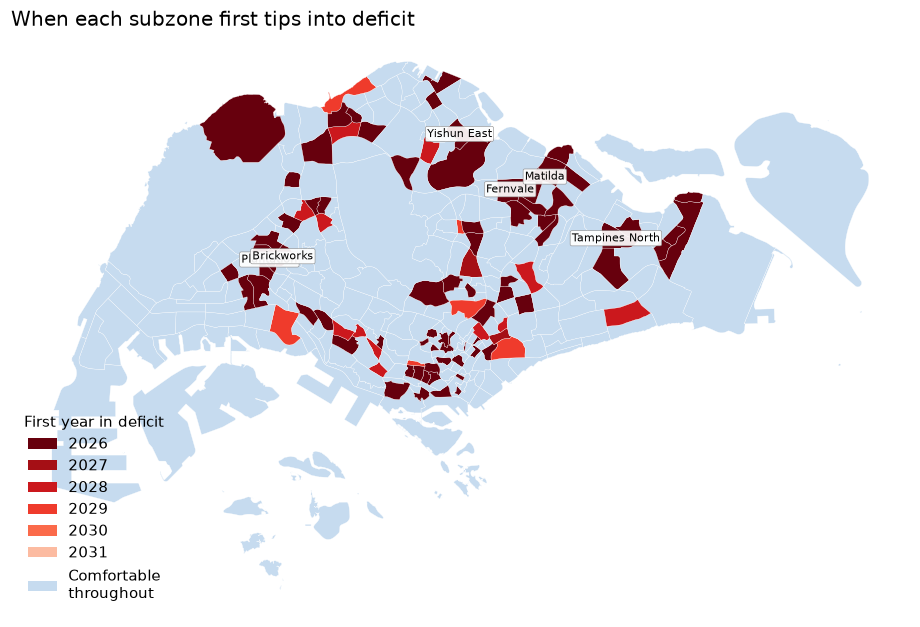

In [32]:
from matplotlib.patches import Patch

YEAR_COLORS = {2026: "#67000d", 2027: "#a50f15", 2028: "#cb181d", 2029: "#ef3b2c", 2030: "#fb6a4a", 2031: "#fcbba1"}
NEVER_COLOR = "#c6dbef"

plot_gdf3 = subzones_gdf.merge(gap_table[["first_deficit_year"]], left_on="subzone", right_index=True, how="left")
plot_gdf3["fill_color"] = plot_gdf3["first_deficit_year"].map(YEAR_COLORS).fillna(NEVER_COLOR)

fig, ax = plt.subplots(figsize=(8.5, 9))
plot_gdf3.plot(color=plot_gdf3["fill_color"], edgecolor="white", linewidth=0.2, ax=ax)
ax.axis("off")
ax.set_title("When each subzone first tips into deficit", fontsize=13, loc="left")

legend_handles = [Patch(facecolor=YEAR_COLORS[y], label=str(y)) for y in FORECAST_YEARS]
legend_handles.append(Patch(facecolor=NEVER_COLOR, label="Comfortable\nthroughout"))
ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=9.5, title="First year in deficit", title_fontsize=9.5)

# Name the subzones that matter most: the 6 biggest 2031 gaps (the same leaders Section 6.4
# tops its priority table with), so the darkest patches on the map aren't anonymous. Drawn
# smallest-gap-first so the single biggest label always ends up on top of any overlap.
top_labeled = gap_table.nlargest(6, f"gap_{FORECAST_YEARS[-1]}").sort_values(f"gap_{FORECAST_YEARS[-1]}")
label_gdf = plot_gdf3[plot_gdf3["subzone"].isin(top_labeled.index)].copy()
label_gdf["centroid"] = label_gdf.geometry.centroid
label_gdf["_order"] = label_gdf["subzone"].map(top_labeled[f"gap_{FORECAST_YEARS[-1]}"])
label_gdf = label_gdf.sort_values("_order")
for i, (_, row) in enumerate(label_gdf.iterrows()):
    ax.annotate(row["subzone"], (row["centroid"].x, row["centroid"].y),
                fontsize=7.5, ha="center", va="center", color="black", zorder=10 + i,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="#888888", linewidth=0.4, alpha=0.92))

fig.tight_layout()
fig.savefig(OUT_CHARTS / "09_first_deficit_year_roadmap.png", bbox_inches="tight")
plt.show()

**Reading it:** darkest red clusters around established towns and mid-build-out estates. Shading fades roughly in step with BTO completion years. Blue areas — comfortable the whole way — are the relocation candidates, not the build list.

**The cascade.** New subzones tipping into deficit each year, and the running total of centres needed.

      newly_at_risk  cumulative_in_deficit  centres_needed_cumulative
year                                                                 
2026             75                     75                        356
2027              2                     77                        373
2028             12                     89                        409
2029              6                     95                        430
2030              0                     95                        434
2031              0                     95                        432


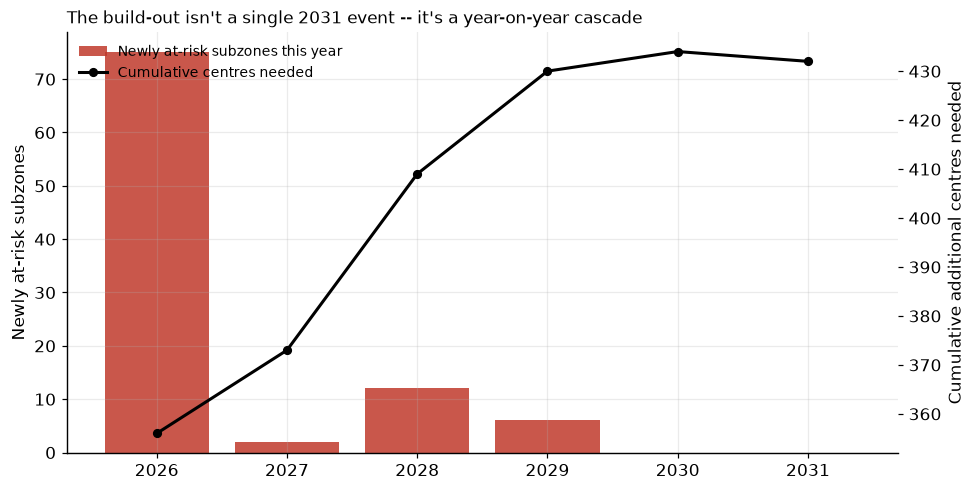

In [33]:
def centres_needed_at(y):
    g = gap_table[f"gap_{y}"]
    return int(np.ceil(g.clip(lower=0) / CAPACITY_PER_CENTRE).sum())

cascade = pd.DataFrame({
    "newly_at_risk": [int((gap_table["first_deficit_year"] == y).sum()) for y in FORECAST_YEARS],
    "cumulative_in_deficit": [int((gap_table["first_deficit_year"] <= y).sum()) for y in FORECAST_YEARS],
    "centres_needed_cumulative": [centres_needed_at(y) for y in FORECAST_YEARS],
}, index=pd.Index(FORECAST_YEARS, name="year"))
print(cascade)

fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.bar(cascade.index, cascade["newly_at_risk"], color=C_DEFICIT, alpha=0.85, label="Newly at-risk subzones this year")
ax1.set_ylabel("Newly at-risk subzones")
ax1.set_xticks(FORECAST_YEARS)
ax2 = ax1.twinx()
ax2.plot(cascade.index, cascade["centres_needed_cumulative"], color="black", marker="o", markersize=5, linewidth=2, label="Cumulative centres needed")
ax2.set_ylabel("Cumulative additional centres needed")
ax2.grid(False)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False, fontsize=9)
ax1.set_title("The build-out isn't a single 2031 event -- it's a year-on-year cascade", fontsize=11, loc="left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "10_deficit_cascade_by_year.png", bbox_inches="tight")
plt.show()

**Reading it:** the deficit builds steadily, not all at once. **Named next** — every subzone in order, so this is actionable, not just a shape.

In [34]:
cascade_detail = gap_table[gap_table["first_deficit_year"].notna()].copy()
cascade_detail = cascade_detail.sort_values(["first_deficit_year", f"gap_{FORECAST_YEARS[-1]}"], ascending=[True, False])
cascade_detail_display = cascade_detail.reset_index()[
    ["subzone", "planning_area", "first_deficit_year", f"gap_{FORECAST_YEARS[-1]}", "bto_share_2031"]
]
cascade_detail_display.columns = [
    "Subzone", "Planning Area", "First Year Short",
    f"{FORECAST_YEARS[-1]} Gap (children, + short / - surplus)", "Share of 2031 Demand from BTO",
]
cascade_detail_display.to_csv(OUT_DATA / "deficit_cascade_by_year.csv", index=False)

for y in FORECAST_YEARS:
    subset = cascade_detail_display[cascade_detail_display["First Year Short"] == y]
    if len(subset):
        names = ", ".join(subset["Subzone"].head(8))
        more = f" (+{len(subset)-8} more)" if len(subset) > 8 else ""
        print(f"{int(y)} ({len(subset)} newly at-risk): {names}{more}")

cascade_detail_display.head(20)

2026 (75 newly at-risk): Brickworks, Tampines North, Yishun East, Matilda, Fernvale, Plantation, Lower Seletar, Waterway East (+67 more)
2027 (2 newly at-risk): Kampong Bugis, Bishan East
2028 (12 newly at-risk): Singapore Polytechnic, Ghim Moh, Queensway, Khatib, Teck Whye, Tanglin Halt, Bedok South, Boon Keng (+4 more)
2029 (6 newly at-risk): Tanjong Rhu, North Coast, Teban Gardens, Ang Mo Kio Town Centre, Alexandra North, Balestier


,Subzone,Planning Area,First Year Short,"2031 Gap (children, + short / - surplus)",Share of 2031 Demand from BTO
0,Brickworks,Bukit Batok,2026.0,3329.401746,0.722594
1,Tampines North,Tampines,2026.0,2766.300573,0.857032
2,Yishun East,Yishun,2026.0,2421.767408,0.467978
3,Matilda,Punggol,2026.0,2144.203423,0.114711
4,Fernvale,Sengkang,2026.0,2108.381643,0.311924
5,Plantation,Tengah,2026.0,1858.760000,1.000000
6,Lower Seletar,Yishun,2026.0,1446.859261,0.409564
7,Waterway East,Punggol,2026.0,1418.501559,0.169312
8,Northshore,Punggol,2026.0,1366.378324,0.995922
9,Park,Tengah,2026.0,1316.640000,1.000000


### 6.6 blind spot

Every number so far assumes "1 centre = 100 kids, full 18mo-6y range." True for planning *new* centres. Not true of every *existing* one:

| Model | Age range | n |
|---|---|---|
| `CC` (Child Care) | 18mo-6y | 1,473 |
| `DS` (Dual Service) | 2mo-6y | 89 |
| `KN` (Kindergarten) | 5-6y only | 185 |
| `EYC` (Early Years Centre) | 2mo-4y | 11 |
| `EYC-DS` (Early Years Centre, Dual Service) | 2mo-4y, with infant care | 59 |

`KN` and `EYC` are partial-range **by design** — a kindergarten can't enrol an 18-month-old. Counting one as "100 kids, any age" overstates what it doesn't serve. Does treating every centre as full-range hide a shortage?

In [35]:
YOUNGER_LEVELS = ["pg", "n1", "n2"]   # ~18mo-4y
OLDER_LEVELS = ["k1", "k2"]           # ~5-6y

centres_gdf["n_all_levels"] = centres_gdf[[f"offers_{l}" for l in ALL_LEVELS]].sum(axis=1)
per_level_cap = CAPACITY_PER_CENTRE / centres_gdf["n_all_levels"].replace(0, np.nan)
centres_gdf["cap_younger"] = per_level_cap * centres_gdf[[f"offers_{l}" for l in YOUNGER_LEVELS]].sum(axis=1)
centres_gdf["cap_older"] = per_level_cap * centres_gdf[[f"offers_{l}" for l in OLDER_LEVELS]].sum(axis=1)

# Each centre's 100-child norm is split evenly across however many of the 6 levels it actually
# runs (including Infant Care, which is then excluded -- its slice is out of our 18mo-6y scope).
# A KN-only centre puts all 100 into "older"; an EYC puts all 100 into "younger"; a full-range
# CC/DS with all 5 childcare levels + infant splits ~17/level, ~50 "younger" / ~33 "older".

supply_split = centres_gdf.groupby("subzone").agg(cap_younger=("cap_younger", "sum"), cap_older=("cap_older", "sum")).reset_index()
supply_split = subzone_list.merge(supply_split, on="subzone", how="left").fillna(0).set_index("subzone")

gap_table["supply_younger"] = supply_split["cap_younger"].reindex(gap_table.index).fillna(0)
gap_table["supply_older"] = supply_split["cap_older"].reindex(gap_table.index).fillna(0)

print(f"National capacity under the flat 100/centre norm:  {gap_table['supply'].sum():,.0f}")
print(f"Split by sub-band -- younger (18mo-4y): {gap_table['supply_younger'].sum():,.0f}, "
      f"older (5-6y): {gap_table['supply_older'].sum():,.0f}, "
      f"sum: {gap_table['supply_younger'].sum() + gap_table['supply_older'].sum():,.0f} "
      "(less than the flat total -- the gap is each centre's Infant Care slice, legitimately out of our scope).")

National capacity under the flat 100/centre norm:  178,700
Split by sub-band -- younger (18mo-4y): 95,978, older (5-6y): 67,555, sum: 163,533 (less than the flat total -- the gap is each centre's Infant Care slice, legitimately out of our scope).


New assumption: split BTO demand the same way, by year-width (3.5 vs 2.0 years).

In [36]:
YOUNGER_YEARS, OLDER_YEARS = 3.5, 2.0  # 18mo-4y spans 3.5 years, 5-6y spans 2.0 years
bto_younger_share = YOUNGER_YEARS / (YOUNGER_YEARS + OLDER_YEARS)

organic_demand_younger = pd.DataFrame(index=pop_indexed.index)
organic_demand_older = pd.DataFrame(index=pop_indexed.index)
for y in FORECAST_YEARS:
    gf = growth_factor_df.loc[y]
    organic_demand_younger[y] = BAND_WEIGHT_0_4 * pop_indexed["Total_0_4"] * gf["factor_0_4"] * PARTICIPATION_RATE
    organic_demand_older[y] = BAND_WEIGHT_5_9 * pop_indexed["Total_5_9"] * gf["factor_5_9"] * PARTICIPATION_RATE

# Sanity check: the two sub-band components should reconstruct the combined organic_demand exactly.
recon_error = (organic_demand_younger + organic_demand_older - organic_demand).abs().max().max()
print(f"Reconstruction check (should be ~0): {recon_error:.2e}")

for y in FORECAST_YEARS:
    gap_table[f"demand_younger_{y}"] = organic_demand_younger[y].reindex(gap_table.index).fillna(0) + bto_demand[y].reindex(gap_table.index).fillna(0) * bto_younger_share
    gap_table[f"demand_older_{y}"] = organic_demand_older[y].reindex(gap_table.index).fillna(0) + bto_demand[y].reindex(gap_table.index).fillna(0) * (1 - bto_younger_share)
    gap_table[f"gap_younger_{y}"] = gap_table[f"demand_younger_{y}"] - gap_table["supply_younger"]
    gap_table[f"gap_older_{y}"] = gap_table[f"demand_older_{y}"] - gap_table["supply_older"]

last_year = FORECAST_YEARS[-1]
n_combined = (gap_table[f"gap_{last_year}"] > 0).sum()
n_younger = (gap_table[f"gap_younger_{last_year}"] > 0).sum()
n_older = (gap_table[f"gap_older_{last_year}"] > 0).sum()
n_either = ((gap_table[f"gap_younger_{last_year}"] > 0) | (gap_table[f"gap_older_{last_year}"] > 0)).sum()

print(f"\nSubzones in deficit, {last_year}, by view:")
print(f"  Combined (current flat model): {n_combined}")
print(f"  Younger band only:             {n_younger}")
print(f"  Older band only:               {n_older}")
print(f"  Either sub-band:               {n_either}")

Reconstruction check (should be ~0): 4.55e-13

Subzones in deficit, 2031, by view:
  Combined (current flat model): 89
  Younger band only:             96
  Older band only:               110
  Either sub-band:               116


### blind spot, quantified

A subzone is **masked** if the combined view says comfortable, but it's actually short in one sub-band. Real shortages Sections 6.1-6.4 would never show.

In [37]:
def find_masked(year):
    combined_ok = gap_table[f"gap_{year}"] <= 0
    younger_short = gap_table[f"gap_younger_{year}"] > 0
    older_short = gap_table[f"gap_older_{year}"] > 0
    out = gap_table[combined_ok & (younger_short | older_short)].copy()
    out["masked_driver"] = np.select(
        [younger_short[out.index] & older_short[out.index], younger_short[out.index], older_short[out.index]],
        ["Both bands short", "Younger (18mo-4y) short", "Older (5-6y) short"],
        default="Both bands short",
    )
    return out.sort_values(f"gap_{year}")

masked_2026 = find_masked(FORECAST_YEARS[0])
masked_2031 = find_masked(FORECAST_YEARS[-1])

print(f"Subzones masked today ({FORECAST_YEARS[0]}): {len(masked_2026)}")
print(f"Subzones masked by {FORECAST_YEARS[-1]}: {len(masked_2031)}")
print(f"\nBreakdown by driver, today:")
print(masked_2026["masked_driver"].value_counts())
print(f"\nWorst-masked subzones today (combined view says comfortable, one or both sub-bands say otherwise):")
cols = ["planning_area", "n_centres", f"gap_{FORECAST_YEARS[0]}", f"gap_younger_{FORECAST_YEARS[0]}", f"gap_older_{FORECAST_YEARS[0]}", "masked_driver"]
masked_labels = {
    "planning_area": "Planning Area",
    "n_centres": "Centres Today",
    f"gap_{FORECAST_YEARS[0]}": f"{FORECAST_YEARS[0]} Combined Gap (children, + short / - surplus)",
    f"gap_younger_{FORECAST_YEARS[0]}": "Younger-Band Gap (18mo-4y)",
    f"gap_older_{FORECAST_YEARS[0]}": "Older-Band Gap (5-6y)",
    "masked_driver": "Which Band Is Short",
}
masked_2026[cols].head(10).rename(columns=masked_labels)

Subzones masked today (2026): 27
Subzones masked by 2031: 27

Breakdown by driver, today:
masked_driver
Older (5-6y) short         15
Younger (18mo-4y) short     7
Both bands short            5
Name: count, dtype: int64

Worst-masked subzones today (combined view says comfortable, one or both sub-bands say otherwise):


,Planning Area,Centres Today,"2026 Combined Gap (children, + short / - surplus)",Younger-Band Gap (18mo-4y),Older-Band Gap (5-6y),Which Band Is Short
subzone,,,,,,
Bedok North,Bedok,27.0,-273.864598,7.573243,-39.771174,Younger (18mo-4y) short
Sembawang Central,Sembawang,19.0,-266.249063,1.922918,-59.838648,Younger (18mo-4y) short
Jurong West Central,Jurong West,21.0,-216.644383,-86.898043,86.920327,Older (5-6y) short
Clementi Central,Clementi,6.0,-151.857778,-114.882633,46.358188,Older (5-6y) short
Bangkit,Bukit Panjang,6.0,-151.681581,-95.767063,27.418816,Older (5-6y) short
Townsville,Ang Mo Kio,6.0,-126.670791,-63.538620,3.534495,Older (5-6y) short
Pei Chun,Toa Payoh,3.0,-105.666159,-98.969759,26.636934,Older (5-6y) short
Sengkang Town Centre,Sengkang,24.0,-99.708425,79.994477,78.630431,Both bands short
Bukit Batok West,Bukit Batok,5.0,-82.148608,46.461380,-95.276655,Younger (18mo-4y) short


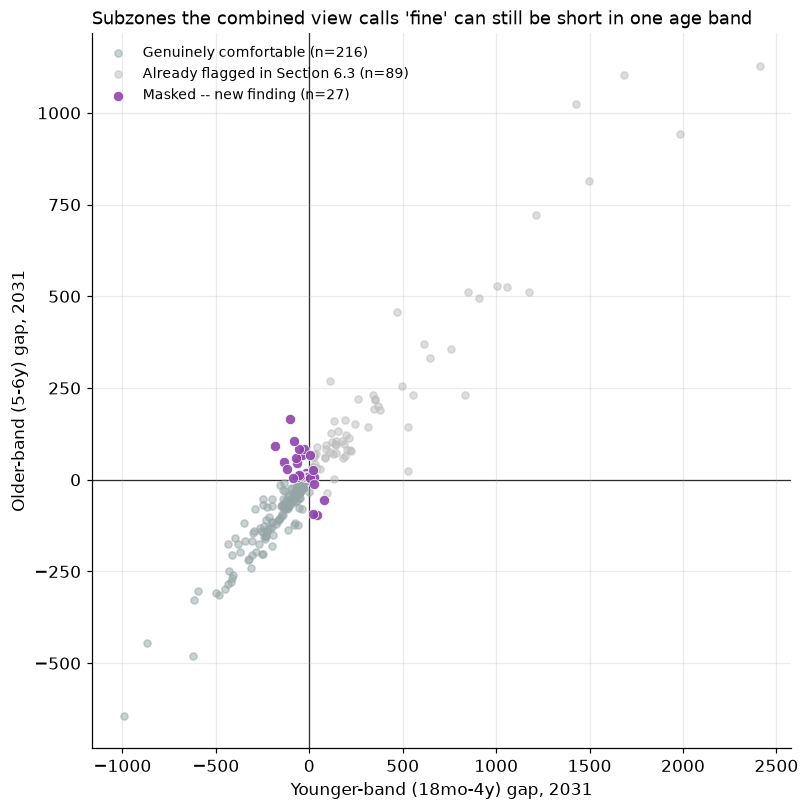

In [38]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
y = FORECAST_YEARS[-1]
already_flagged = gap_table[f"gap_{y}"] > 0
is_masked = gap_table.index.isin(masked_2031.index)
comfortable = ~already_flagged & ~is_masked

ax.scatter(gap_table.loc[comfortable, f"gap_younger_{y}"], gap_table.loc[comfortable, f"gap_older_{y}"],
           s=22, alpha=0.5, color=C_NEUTRAL, label=f"Genuinely comfortable (n={comfortable.sum()})")
ax.scatter(gap_table.loc[already_flagged, f"gap_younger_{y}"], gap_table.loc[already_flagged, f"gap_older_{y}"],
           s=22, alpha=0.5, color="#bdbdbd", label=f"Already flagged in Section 6.3 (n={already_flagged.sum()})")
ax.scatter(gap_table.loc[is_masked, f"gap_younger_{y}"], gap_table.loc[is_masked, f"gap_older_{y}"],
           s=45, alpha=0.9, color=C_HIGHLIGHT, edgecolor="white", linewidth=0.5, label=f"Masked -- new finding (n={is_masked.sum()})")

ax.axhline(0, color="black", linewidth=0.8, zorder=0)
ax.axvline(0, color="black", linewidth=0.8, zorder=0)
ax.set_xlabel(f"Younger-band (18mo-4y) gap, {y}")
ax.set_ylabel(f"Older-band (5-6y) gap, {y}")
ax.set_title("Subzones the combined view calls 'fine' can still be short in one age band", fontsize=11.5, loc="left")
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "11_subband_masked_scatter.png", bbox_inches="tight")
plt.show()

**Reading it:** purple points = subzones the combined view calls comfortable, but short once split by age band. Grey = already flagged anyway. The purple ones are the new finding.

### What this changes for the priority list

Even subzones already flagged in 6.4 aren't uniform — some short on playgroup/nursery, some on kindergarten. Matters for *what* gets built, not just where.

In [39]:
# priority_build was built from gap_table *before* Section 6.6 added the sub-band columns --
# re-select the same rows from the current gap_table (by index) rather than copying the stale
# snapshot, so gap_younger_*/gap_older_* are actually present.
priority_with_driver = gap_table.loc[priority_build.index].copy()
y = FORECAST_YEARS[-1]
priority_with_driver["younger_share_of_gap"] = (
    priority_with_driver[f"gap_younger_{y}"].clip(lower=0)
    / (priority_with_driver[f"gap_younger_{y}"].clip(lower=0) + priority_with_driver[f"gap_older_{y}"].clip(lower=0)).replace(0, np.nan)
)
priority_with_driver["primary_driver"] = np.select(
    [priority_with_driver["younger_share_of_gap"] > 0.65, priority_with_driver["younger_share_of_gap"] < 0.35],
    ["Younger-band (18mo-4y) driven", "Older-band (5-6y) driven"],
    default="Mixed -- both bands short",
)
print(priority_with_driver["primary_driver"].value_counts())

driver_cols = ["planning_area", f"gap_{y}", f"gap_younger_{y}", f"gap_older_{y}", "primary_driver"]
priority_with_driver[driver_cols].to_csv(OUT_DATA / "priority_build_list_with_subbands.csv")
masked_2026.to_csv(OUT_DATA / "masked_subzones_2026.csv")
masked_2031.to_csv(OUT_DATA / "masked_subzones_2031.csv")
gap_table.to_csv(OUT_DATA / "gap_table_all_subzones.csv")  # re-export with the new sub-band columns
print("\nExported priority_build_list_with_subbands.csv, masked_subzones_2026.csv, masked_subzones_2031.csv, "
      "and refreshed gap_table_all_subzones.csv with sub-band columns.")

primary_driver
Mixed -- both bands short        52
Younger-band (18mo-4y) driven    27
Older-band (5-6y) driven         14
Name: count, dtype: int64

Exported priority_build_list_with_subbands.csv, masked_subzones_2026.csv, masked_subzones_2031.csv, and refreshed gap_table_all_subzones.csv with sub-band columns.


**Net effect:** the combined view is still right for "how many, roughly where" — simpler, and the two views agree on most subzones. But before committing to a site, this sub-band check is free and can change *what* gets built — and catches subzones the combined view misses entirely.

## 7. Robustness Checks

Three checks: **(7.1)** does our modelled gap match an independent, live signal? **(7.2)** how much does the list move if the BTO yield is off by 50%? **(7.3)** a single-town spot-check against the source article.

### 7.1 Cross-check against live vacancy

`pct_levels_full` comes straight from ECDA's listing, no modelling. If our gap is real, high-deficit subzones should show more `Full` centres today.

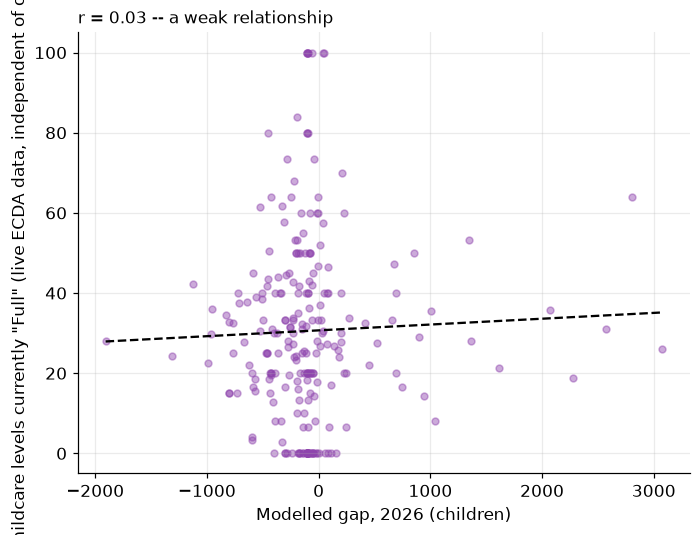

Correlation between modelled 2026 gap and live '% levels full': 0.03 -- essentially no relationship.
That's a genuine, unflattering result. Worth taking seriously rather than explaining away -- see the note below.


In [40]:
valid = gap_table[gap_table["n_centres"] >= 1].dropna(subset=["pct_full_avg"]).copy()
corr = valid[f"gap_{FORECAST_YEARS[0]}"].corr(valid["pct_full_avg"])

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(valid[f"gap_{FORECAST_YEARS[0]}"], valid["pct_full_avg"] * 100, alpha=0.45, s=20, color=C_HIGHLIGHT)
z = np.polyfit(valid[f"gap_{FORECAST_YEARS[0]}"], valid["pct_full_avg"] * 100, 1)
xs = np.linspace(valid[f"gap_{FORECAST_YEARS[0]}"].min(), valid[f"gap_{FORECAST_YEARS[0]}"].max(), 50)
ax.plot(xs, np.poly1d(z)(xs), color="black", linewidth=1.5, linestyle="--")
ax.set_xlabel(f"Modelled gap, {FORECAST_YEARS[0]} (children)")
ax.set_ylabel('% of childcare levels currently "Full" (live ECDA data, independent of our model)')
ax.set_title(f"r = {corr:.2f} -- a weak relationship", fontsize=11, loc="left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "07_validation_gap_vs_live_vacancy.png", bbox_inches="tight")
plt.show()

print(f"Correlation between modelled 2026 gap and live '% levels full': {corr:.2f} -- essentially no relationship.")
print("That's a genuine, unflattering result. Worth taking seriously rather than explaining away -- see the note below.")

**Came back weak — worth saying straight, not burying.** Two different things: `pct_levels_full` reflects where families *enrolled* (popular providers, waitlists, commute patterns) — not where children *live*, which is what our model assumes.

Near-zero correlation doesn't undermine the demand forecast — population and BTO timing are independently checkable facts. It just means live vacancy and resident-based gap answer different questions. If anything, this argues for the accessibility follow-up in Section 10.2.

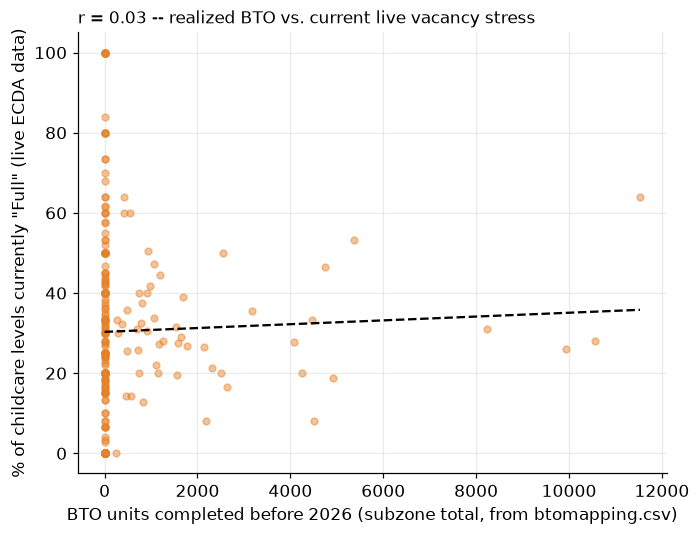

Correlation, realized pre-2026 BTO units vs. live % levels full: 0.03
Mean % levels full, subzones WITH realized BTO housing (n=53): 31.4%
Mean % levels full, subzones WITHOUT realized BTO housing (n=185): 30.3%


In [41]:
realized_bto = bto[bto["completion_year"] < TODAY_YEAR].groupby("subzone")["units"].sum()

h2_check = gap_table[["pct_full_avg", "n_centres"]].copy()
h2_check["realized_bto_units"] = realized_bto.reindex(h2_check.index).fillna(0)
h2_valid = h2_check[h2_check["n_centres"] >= 1].dropna(subset=["pct_full_avg"])

corr_h2_indep = h2_valid["realized_bto_units"].corr(h2_valid["pct_full_avg"])
has_realized_bto = h2_valid["realized_bto_units"] > 0

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(h2_valid["realized_bto_units"], h2_valid["pct_full_avg"] * 100, alpha=0.45, s=20, color=C_BTO)
z2 = np.polyfit(h2_valid["realized_bto_units"], h2_valid["pct_full_avg"] * 100, 1)
xs2 = np.linspace(h2_valid["realized_bto_units"].min(), h2_valid["realized_bto_units"].max(), 50)
ax.plot(xs2, np.poly1d(z2)(xs2), color="black", linewidth=1.5, linestyle="--")
ax.set_xlabel("BTO units completed before 2026 (subzone total, from btomapping.csv)")
ax.set_ylabel('% of childcare levels currently "Full" (live ECDA data)')
ax.set_title(f"r = {corr_h2_indep:.2f} -- realized BTO vs. current live vacancy stress", fontsize=11, loc="left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "13_h2_independent_check.png", bbox_inches="tight")
plt.show()

print(f"Correlation, realized pre-2026 BTO units vs. live % levels full: {corr_h2_indep:.2f}")
print(f"Mean % levels full, subzones WITH realized BTO housing (n={has_realized_bto.sum()}): {h2_valid.loc[has_realized_bto, 'pct_full_avg'].mean():.1%}")
print(f"Mean % levels full, subzones WITHOUT realized BTO housing (n={(~has_realized_bto).sum()}): {h2_valid.loc[~has_realized_bto, 'pct_full_avg'].mean():.1%}")

### 7.1b Is H2 circular?

Section 5.4 builds BTO directly into demand, so "BTO subzones get worse gaps" risks being true by construction. Cleaner test: **realized** (pre-2026) BTO units vs. **today's** live vacancy — neither touches the model.

**Null result: r=0.03.** Subzones with realized BTO show almost the same Full-rate (31.4%) as those without (30.3%). Doesn't confirm H2 independently. Consistent with 7.1's finding that live vacancy tracks something else — which specific centres are popular, not resident population.

**Honest position: H2 is a reasonable, well-sourced assumption — not an independently proven fact.** The 0.38 correlation in Section 8 follows largely from how we build BTO into demand in the first place.

### 7.2 Sensitivity to the BTO yield

Re-run at half and 1.5x the 0.28 assumption, check how much the top-15 list reshuffles — it's the ranking that matters, not the exact numbers.

In [42]:
base_top15 = set(priority_build.head(15).index)
sensitivity_overlap = {}
for mult, label in [(0.5, "Low (0.14/unit)"), (1.0, "Base (0.28/unit)"), (1.5, "High (0.42/unit)")]:
    bto_demand_s = compute_bto_demand(CHILD_YIELD_PER_BTO_UNIT * mult)
    demand_2031_s = (organic_demand[FORECAST_YEARS[-1]] + bto_demand_s[FORECAST_YEARS[-1]]).reindex(subzone_master.index).fillna(0)
    gap_2031_s = demand_2031_s - gap_table["supply"]
    top15_s = set(gap_2031_s.sort_values(ascending=False).head(15).index)
    sensitivity_overlap[label] = len(top15_s & base_top15)

print("Overlap with the base-case top-15 priority list, at each yield assumption:")
for label, overlap in sensitivity_overlap.items():
    print(f"  {label}: {overlap}/15 subzones unchanged")
print("\nThe list is a *priority ordering*, not a claim that any single subzone's exact child count is precise -- "
      "this is the check that the ordering is stable enough to act on.")

Overlap with the base-case top-15 priority list, at each yield assumption:
  Low (0.14/unit): 14/15 subzones unchanged
  Base (0.28/unit): 15/15 subzones unchanged
  High (0.42/unit): 13/15 subzones unchanged

The list is a *priority ordering*, not a claim that any single subzone's exact child count is precise -- this is the check that the ordering is stable enough to act on.


### 7.3 One more spot-check: Punggol

The source article names Punggol specifically — shortages concentrated in infant/playgroup, not kindergarten.

In [43]:
punggol = gap_table[gap_table["planning_area"] == "Punggol"].sort_values(f"gap_{FORECAST_YEARS[0]}", ascending=False)
display_cols = ["n_centres", f"gap_{FORECAST_YEARS[0]}", f"gap_{FORECAST_YEARS[-1]}",
                f"gap_younger_{FORECAST_YEARS[-1]}", f"gap_older_{FORECAST_YEARS[-1]}", "category"]
punggol_labels = {
    "n_centres": "Centres Today",
    f"gap_{FORECAST_YEARS[0]}": f"{FORECAST_YEARS[0]} Gap (children, + short / - surplus)",
    f"gap_{FORECAST_YEARS[-1]}": f"{FORECAST_YEARS[-1]} Gap (children, + short / - surplus)",
    f"gap_younger_{FORECAST_YEARS[-1]}": "Younger-Band Gap (18mo-4y)",
    f"gap_older_{FORECAST_YEARS[-1]}": "Older-Band Gap (5-6y)",
    "category": "Status",
}
punggol_centres = punggol["n_centres"].sum()
print(f"Punggol: {punggol_centres:.0f} centres across {len(punggol)} subzones")
punggol[display_cols].rename(columns=punggol_labels)

Punggol: 87 centres across 7 subzones


,Centres Today,"2026 Gap (children, + short / - surplus)","2031 Gap (children, + short / - surplus)",Younger-Band Gap (18mo-4y),Older-Band Gap (5-6y),Status
subzone,,,,,,
Matilda,14.0,2070.211403,2144.203423,1496.708001,814.162088,Urgent: deficit today
Waterway East,24.0,1615.248268,1418.501559,1173.464980,511.703246,Urgent: deficit today
Northshore,16.0,1367.094995,1366.378324,1057.023944,526.021047,Urgent: deficit today
Punggol Town Centre,15.0,452.404262,350.479893,526.176069,24.303824,Urgent: deficit today
Coney Island,0.0,0.000000,0.000000,0.000000,0.000000,Comfortable
Punggol Canal,0.0,0.000000,0.000000,0.000000,0.000000,Comfortable
Punggol Field,18.0,-12.344044,-97.777813,-104.662806,165.218326,Relocation candidate


Every populated Punggol subzone comes back **Urgent**, younger-band deficit roughly double the older-band — matches the article. Three were already in our top-10 before this check ran. One data point, not proof — a sanity check on top of the two above.

## 8. Scoring the Three Hypotheses

Back to 1.3 — one piece of evidence per hypothesis.

In [44]:
print("=" * 70)
print("H1: spatial misallocation, not aggregate shortage")
print("=" * 70)
print(f"National utilisation (2024): {natl.loc[2024,'utilisation']:.0%}")
print(f"Share of subzones in deficit today: {deficit_share_2026:.0%}")
print(f"Gap range today: {gap_table[f'gap_{FORECAST_YEARS[0]}'].min():,.0f} to {gap_table[f'gap_{FORECAST_YEARS[0]}'].max():,.0f} children")

total_deficit_2031 = gap_table.loc[gap_table[f"gap_{FORECAST_YEARS[-1]}"] > 0, f"gap_{FORECAST_YEARS[-1]}"].sum()
total_surplus_2031 = -gap_table.loc[gap_table[f"gap_{FORECAST_YEARS[-1]}"] < 0, f"gap_{FORECAST_YEARS[-1]}"].sum()
print(f"\nEven in {FORECAST_YEARS[-1]}: total shortfall across deficit subzones = {total_deficit_2031:,.0f} children, "
      f"vs. total spare capacity across surplus subzones = {total_surplus_2031:,.0f} children.")
print(f"That's {total_surplus_2031/total_deficit_2031:.1f}x more spare capacity nationally than the total shortfall -- "
      "the system has more than enough capacity in aggregate, just not where it's needed.")

print("\n" + "=" * 70)
print("H2: BTO completions are a leading indicator of new shortages")
print("=" * 70)
bto_total_2031 = gap_table[f"bto_{FORECAST_YEARS[-1]}"]
corr_h2 = bto_total_2031.corr(gap_table["gap_trend"])
has_bto = bto_total_2031 > 0
print(f"Correlation, BTO-driven 2031 demand vs. gap trend (2026->2031): {corr_h2:.2f}")
print(f"Mean gap trend, subzones WITH BTO pipeline (n={has_bto.sum()}): {gap_table.loc[has_bto,'gap_trend'].mean():+.1f}")
print(f"Mean gap trend, subzones WITHOUT BTO pipeline (n={(~has_bto).sum()}): {gap_table.loc[~has_bto,'gap_trend'].mean():+.1f}")
emerging = gap_table["category"] == "Emerging: deficit by 2031"
print(f"Share of 'Emerging' subzones with active BTO pipeline: {has_bto[emerging].mean():.0%}")

print("\n" + "=" * 70)
print("H3: falling fertility eases pressure in mature, non-BTO estates")
print("=" * 70)
reloc = gap_table["category"] == "Relocation candidate"
urgent_emerging = gap_table["category"].isin(["Urgent: deficit today", "Emerging: deficit by 2031"])
print(f"Share of relocation candidates with ZERO BTO pipeline: {(~has_bto)[reloc].mean():.0%}")
print(f"Share of urgent/emerging subzones with ZERO BTO pipeline: {(~has_bto)[urgent_emerging].mean():.0%}")
print(f"National age 0-4 CAGR 2020-2025 (from Section 3.4): {cagr_recent_0_4:.2%}/yr")

H1: spatial misallocation, not aggregate shortage
National utilisation (2024): 77%
Share of subzones in deficit today: 23%
Gap range today: -1,906 to 3,073 children

Even in 2031: total shortfall across deficit subzones = 37,836 children, vs. total spare capacity across surplus subzones = 50,510 children.
That's 1.3x more spare capacity nationally than the total shortfall -- the system has more than enough capacity in aggregate, just not where it's needed.

H2: BTO completions are a leading indicator of new shortages
Correlation, BTO-driven 2031 demand vs. gap trend (2026->2031): 0.38
Mean gap trend, subzones WITH BTO pipeline (n=86): +125.6
Mean gap trend, subzones WITHOUT BTO pipeline (n=246): -10.1
Share of 'Emerging' subzones with active BTO pipeline: 100%

H3: falling fertility eases pressure in mature, non-BTO estates
Share of relocation candidates with ZERO BTO pipeline: 79%
Share of urgent/emerging subzones with ZERO BTO pipeline: 38%
National age 0-4 CAGR 2020-2025 (from Secti

**Verdict:**

- **H1 — CONFIRMED.** 77% national utilisation, yet 23% of subzones short today; even in 2031, surplus (50,510) beats shortfall (37,836) 1.3x. Comfortable nationally, mismatched locally — exactly H1.
- **H2 — PARTIALLY CONFIRMED.** Inside the model: r=0.38, +126 vs -10 gap change, 100% of Emerging subzones have BTO. But BTO is built into demand by construction. The independent check (7.1b) finds ~no relationship (r=0.03). Treat as a defensible assumption, not proven fact.
- **H3 — CONFIRMED.** 79% of growing-surplus subzones have zero BTO, matching under-5 population shrinking ~2%/year since 2020.

## 9. Beyond the One-Off Forecast: A Tool for ECDA

ECDA wants to re-run this whenever data updates, not commission a fresh study each time. This notebook is most of the way there.

### 9.1 What it does

Same four steps as Sections 4-6, on a schedule: **ingest** new data, **recompute**, **surface** an updated map/list with a diff against last run, **log** every run's inputs and outputs.

### 9.2 A minimal MVP

Scope: this notebook as three functions (`load_data()`, `compute_gap()`, `render_outputs()`), fronted by a Streamlit dashboard. Upload refreshed data, adjust the two judgment-call sliders, download the result. Buildable in days — a wrapper, not a rebuild.

### 9.3 How it would actually be deployed

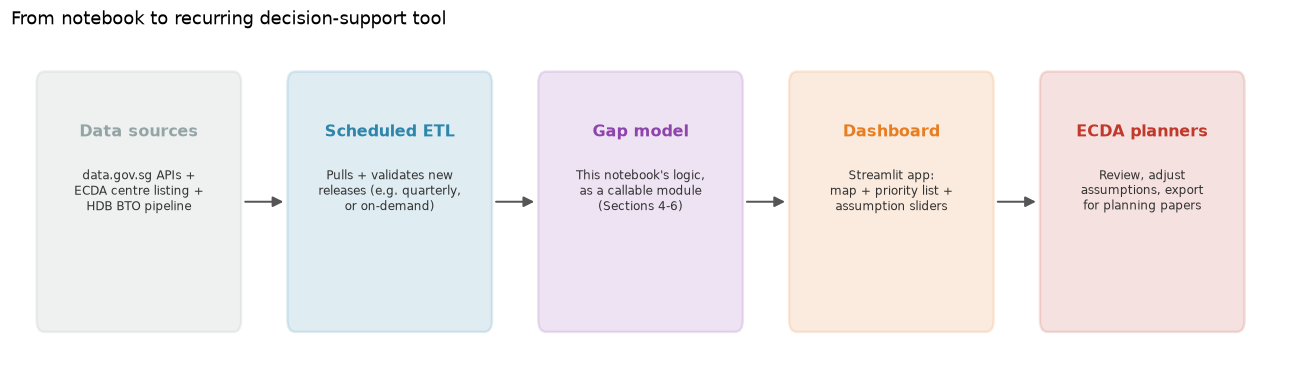

In [45]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 3.6))
stages = [
    ("Data sources", "data.gov.sg APIs +\nECDA centre listing +\nHDB BTO pipeline", C_NEUTRAL),
    ("Scheduled ETL", "Pulls + validates new\nreleases (e.g. quarterly,\nor on-demand)", C_SURPLUS),
    ("Gap model", "This notebook's logic,\nas a callable module\n(Sections 4-6)", C_HIGHLIGHT),
    ("Dashboard", "Streamlit app:\nmap + priority list +\nassumption sliders", C_BTO),
    ("ECDA planners", "Review, adjust\nassumptions, export\nfor planning papers", C_DEFICIT),
]
n = len(stages)
box_w, box_h, gap = 2.0, 1.7, 0.55
x0 = 0.3
for i, (title, desc, color) in enumerate(stages):
    x = x0 + i * (box_w + gap)
    box = FancyBboxPatch((x, 0.3), box_w, box_h, boxstyle="round,pad=0.04,rounding_size=0.08",
                          facecolor=color, alpha=0.15, edgecolor=color, linewidth=1.6)
    ax.add_patch(box)
    ax.text(x + box_w / 2, 0.3 + box_h - 0.32, title, ha="center", va="top", fontsize=10.5, fontweight="bold", color=color)
    ax.text(x + box_w / 2, 0.3 + box_h - 0.62, desc, ha="center", va="top", fontsize=8, color="#333333")
    if i < n - 1:
        arrow = FancyArrowPatch((x + box_w + 0.05, 0.3 + box_h / 2), (x + box_w + gap - 0.05, 0.3 + box_h / 2),
                                 arrowstyle="-|>", mutation_scale=14, color="#555555", linewidth=1.3)
        ax.add_patch(arrow)

ax.set_xlim(0, x0 + n * (box_w + gap))
ax.set_ylim(0, 2.3)
ax.axis("off")
ax.set_title("From notebook to recurring decision-support tool", fontsize=12, loc="left")
fig.tight_layout()
fig.savefig(OUT_CHARTS / "08_tool_architecture.png", bbox_inches="tight")
plt.show()

**The diagram:** data sources -> scheduled ETL -> this notebook's gap logic -> dashboard. No new tech, just the existing analysis on a schedule.

**Hosting:** GovTech commercial cloud, SingPass/AD access control, ECDA planning staff only.
**Refresh:** quarterly for population/BTO, monthly for centre openings/closures, plus on-demand.
**Governance:** every run versioned against its inputs and assumptions — so "why is subzone X ranked #3" always traces to a specific run.

## 10. Limitations, and What We'd Do With More Time

Every assumption, stated where it's used:

| # | Assumption | Value used | Set in |
|---|---|---|---|
| 1 | Childcare capacity per centre | 100 children (given in the brief) | — |
| 2 | Age-band apportionment | 0.70 x age 0-4, 0.40 x age 5-9 | Section 5.1 |
| 3 | Formal-care participation rate | ~62.6%, modelled from 2020 data | Section 5.2 |
| 4 | BTO child-yield | 0.28 children per new unit | Section 5.4 |
| 5 | Per-level capacity split | Even split across levels a centre runs | Section 6.6 |
| 6 | BTO age-split | 3.5 vs 2.0 year-width ratio | Section 6.6 |

### 10.1 What would most change the answer

1. **Population is a proxy, not a measurement.** Real enrolment/waitlist data would replace the biggest assumption — the flat 62-63% participation rate.
2. **BTO yield (0.28) is an assumption, not fitted.** Ordering is stable to it; scale isn't. Real HDB occupancy data would calibrate it properly.
3. **Population is a 6-year-old Census snapshot**, aged on a national trend. 2030 Census will be a real test.
4. **The 0.70/0.40 age-band split** assumes ages spread evenly within each band. True single-year data would remove this.
5. **The even per-level capacity split (6.6)** likely understates the younger-band squeeze, since younger levels run smaller class sizes in practice. Real per-level capacity would fix this directly.

## 11. Summary of Findings & Recommendations

**An allocation problem, not a capacity one.** National utilisation: 75-89% since 2013 (77% in 2024). Yet 23% of subzones are short today, and even in 2031 the surplus (~50,500) beats the shortfall (~37,800) 1.33x.

**H1 and H3 held up clean; H2 held up inside the model, not independently (Section 8).**

**Not just where — also when and which age band.** 75 short today, 12 more in 2028, little changes after 2029. Splitting by age band finds 27 more subzones short in one band, invisible in the flat view.




In [46]:
summary = {
    "national_utilisation_2024": round(float(natl.loc[2024, "utilisation"]), 4),
    "national_utilisation_range": [round(float(natl["utilisation"].min()), 4), round(float(natl["utilisation"].max()), 4)],
    "subzones_analysed": int(len(gap_table)),
    "share_subzones_in_deficit_2026": round(float(deficit_share_2026), 4),
    "gap_range_2026": [round(float(gap_table[f"gap_{FORECAST_YEARS[0]}"].min()), 1), round(float(gap_table[f"gap_{FORECAST_YEARS[0]}"].max()), 1)],
    "n_urgent_deficit_today": int((gap_table["category"] == "Urgent: deficit today").sum()),
    "n_emerging_deficit_by_2031": int((gap_table["category"] == "Emerging: deficit by 2031").sum()),
    "n_relocation_candidates": int((gap_table["category"] == "Relocation candidate").sum()),
    "total_additional_centres_needed_2031": float(gap_table["centres_needed_2031"].sum()),
    "total_deficit_2031": round(float(total_deficit_2031), 1),
    "total_surplus_2031": round(float(total_surplus_2031), 1),
    "surplus_to_deficit_ratio_2031": round(float(total_surplus_2031 / total_deficit_2031), 2),
    "h2_correlation_bto_vs_gap_trend": round(float(corr_h2), 3),
    "h2_independent_check_corr_realized_bto_vs_live_full_pct": round(float(corr_h2_indep), 3),
    "h1_validation_corr_gap_vs_live_full_pct": round(float(corr), 3),
    "participation_rate_assumption": round(float(PARTICIPATION_RATE), 4),
    "bto_child_yield_assumption": CHILD_YIELD_PER_BTO_UNIT,
    "forecast_years": FORECAST_YEARS,
    "capacity_per_centre_norm": CAPACITY_PER_CENTRE,
    "top_10_priority_subzones": priority_build.head(10).index.tolist(),
    "subband_masked_subzones_2026": int(len(masked_2026)),
    "subband_masked_subzones_2031": int(len(masked_2031)),
    "subband_masked_driver_breakdown_2026": masked_2026["masked_driver"].value_counts().to_dict(),
    "subband_priority_driver_breakdown": priority_with_driver["primary_driver"].value_counts().to_dict(),
}

with open(OUT_DATA / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "national_utilisation_2024": 0.7676,
  "national_utilisation_range": [
    0.7492,
    0.894
  ],
  "subzones_analysed": 332,
  "share_subzones_in_deficit_2026": 0.2259,
  "gap_range_2026": [
    -1906.5,
    3072.7
  ],
  "n_urgent_deficit_today": 75,
  "n_emerging_deficit_by_2031": 18,
  "n_relocation_candidates": 43,
  "total_additional_centres_needed_2031": 432.0,
  "total_deficit_2031": 37835.8,
  "total_surplus_2031": 50510.5,
  "surplus_to_deficit_ratio_2031": 1.33,
  "h2_correlation_bto_vs_gap_trend": 0.384,
  "h2_independent_check_corr_realized_bto_vs_live_full_pct": 0.032,
  "h1_validation_corr_gap_vs_live_full_pct": 0.035,
  "participation_rate_assumption": 0.6264,
  "bto_child_yield_assumption": 0.28,
  "forecast_years": [
    2026,
    2027,
    2028,
    2029,
    2030,
    2031
  ],
  "capacity_per_centre_norm": 100,
  "top_10_priority_subzones": [
    "Brickworks",
    "Tampines North",
    "Yishun East",
    "Matilda",
    "Fernvale",
    "Plantation",
    "Lower S